# Análise de Dados Exploratória

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_DIR = Path().cwd().parent / "data"
DATA_DIR

PosixPath('/Users/marcosilva/Projetos/FAMaringa/data')

## Avaliando arquivo FIS_NFITEM.CSV

In [2]:
# Importando dados
df_raw = pd.read_csv(DATA_DIR / "FIS_NFITEM.csv", sep=";")

# Verificando dimensões do dataset
print("Número de linhas:", df_raw.shape[0])
print("Número de colunas:", df_raw.shape[1])

Número de linhas: 49614
Número de colunas: 29


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 49614 entries, 0 to 49613
Data columns (total 29 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CD_EMPRESA       49614 non-null  int64  
 1   NR_FATURA        49614 non-null  int64  
 2   DT_FATURA        49614 non-null  str    
 3   NR_ITEM          49614 non-null  int64  
 4   U_VERSION        49614 non-null  str    
 5   CD_EMPFAT        49614 non-null  int64  
 6   CD_GRUPOEMPRESA  49614 non-null  int64  
 7   CD_OPERADOR      49614 non-null  int64  
 8   DT_CADASTRO      49614 non-null  str    
 9   CD_TIPI          49393 non-null  float64
 10  CD_CFOP          49614 non-null  int64  
 11  CD_PRODUTO       49614 non-null  int64  
 12  CD_DECRETO       0 non-null      float64
 13  CD_ESPECIE       49614 non-null  str    
 14  CD_CST           49614 non-null  int64  
 15  IN_DESCONTO      40251 non-null  str    
 16  PR_DESCONTO      40251 non-null  float64
 17  DS_PRODUTO       49614 

In [4]:
# Conferindo amostra
df_raw.sample(10).T

In [5]:
# Verificando os tipos de dados das colunas
print(df_raw.dtypes)

CD_EMPRESA           int64
NR_FATURA            int64
DT_FATURA              str
NR_ITEM              int64
U_VERSION              str
CD_EMPFAT            int64
CD_GRUPOEMPRESA      int64
CD_OPERADOR          int64
DT_CADASTRO            str
CD_TIPI            float64
CD_CFOP              int64
CD_PRODUTO           int64
CD_DECRETO         float64
CD_ESPECIE             str
CD_CST               int64
IN_DESCONTO            str
PR_DESCONTO        float64
DS_PRODUTO             str
QT_FATURADO          int64
VL_TOTALBRUTO      float64
VL_TOTALDESC       float64
VL_TOTALLIQUIDO    float64
VL_UNITBRUTO       float64
VL_UNITDESC        float64
VL_UNITLIQUIDO     float64
VL_DESPACESSOR     float64
VL_FRETE           float64
VL_SEGURO          float64
CD_DEST            float64
dtype: object


In [6]:
# Conferindo estatisticas descritivas
df_raw.describe().T

## Avaliando Valores Ausentes

In [7]:
# Conferindo valores nulos
((df_raw.isnull().sum() / df_raw.shape[0]) *100).round(4).sort_values(ascending=False).head(15)

CD_DEST            100.0000
CD_DECRETO         100.0000
VL_SEGURO           67.3399
VL_FRETE            67.3378
VL_DESPACESSOR      67.3378
PR_DESCONTO         18.8717
IN_DESCONTO         18.8717
VL_UNITDESC         18.7931
VL_TOTALDESC        18.7931
CD_TIPI              0.4454
VL_UNITLIQUIDO       0.0000
VL_UNITBRUTO         0.0000
VL_TOTALLIQUIDO      0.0000
VL_TOTALBRUTO        0.0000
QT_FATURADO          0.0000
dtype: float64

In [8]:
df_raw[df_raw['VL_SEGURO'] != 0.0].dropna(subset=['VL_SEGURO'])

In [9]:
df_raw[df_raw['VL_SEGURO'] == 0.0]

In [10]:
df_raw.shape[0] - (
    df_raw[df_raw['VL_SEGURO'].isna()].shape[0] 
    + 
    df_raw[df_raw['VL_SEGURO'] == 0.0].shape[0]
    )


0

A coluna ```VL_SEGURO``` apresenta todos os registros não nulos igual a Zero

In [11]:
print("Valores únicos da coluna VL_DESPACESSOR:", df_raw[df_raw['VL_DESPACESSOR'] != 0.0].dropna(subset=['VL_DESPACESSOR'])['VL_DESPACESSOR'].unique().shape[0])
print("Quantidade de registros com VL_DESPACESSOR diferente de 0.0:", df_raw[df_raw['VL_DESPACESSOR'] != 0.0].dropna(subset=['VL_DESPACESSOR']).shape[0])

Valores únicos da coluna VL_DESPACESSOR: 4
Quantidade de registros com VL_DESPACESSOR diferente de 0.0: 6


In [12]:
# Analisando colunas de Valores
cols = ["VL_SEGURO", "VL_FRETE", "VL_DESPACESSOR", "VL_UNITDESC", "VL_TOTALDESC",]

for col in cols:
    print(col)
    print(f"Valores únicos da coluna {col}:", df_raw[df_raw[col] != 0.0].dropna(subset=[col])[col].unique().shape[0])
    print(f"Quantidade de registros com {col} diferente de 0.0:", df_raw[df_raw[col] != 0.0].dropna(subset=[col]).shape[0])
    print("-"*70)

VL_SEGURO
Valores únicos da coluna VL_SEGURO: 0
Quantidade de registros com VL_SEGURO diferente de 0.0: 0
----------------------------------------------------------------------
VL_FRETE
Valores únicos da coluna VL_FRETE: 4850
Quantidade de registros com VL_FRETE diferente de 0.0: 12517
----------------------------------------------------------------------
VL_DESPACESSOR
Valores únicos da coluna VL_DESPACESSOR: 4
Quantidade de registros com VL_DESPACESSOR diferente de 0.0: 6
----------------------------------------------------------------------
VL_UNITDESC
Valores únicos da coluna VL_UNITDESC: 17
Quantidade de registros com VL_UNITDESC diferente de 0.0: 50
----------------------------------------------------------------------
VL_TOTALDESC
Valores únicos da coluna VL_TOTALDESC: 20
Quantidade de registros com VL_TOTALDESC diferente de 0.0: 50
----------------------------------------------------------------------


In [13]:
# Analisando Preço de Desconto
cols = ["PR_DESCONTO"]

for col in cols:
    print(col)
    print(f"Valores únicos da coluna {col}:", df_raw[df_raw[col] != 0.0].dropna(subset=[col])[col].unique().shape[0])
    print(f"Quantidade de registros com {col} diferente de 0.0:", df_raw[df_raw[col] != 0.0].dropna(subset=[col]).shape[0])
    print("-"*70)
    
df_raw[df_raw['PR_DESCONTO'] != 0.0].dropna(subset=['PR_DESCONTO']).T

PR_DESCONTO
Valores únicos da coluna PR_DESCONTO: 9
Quantidade de registros com PR_DESCONTO diferente de 0.0: 11
----------------------------------------------------------------------


In [14]:
# Analisando Cod. TIPI
cols = ["CD_TIPI"]

for col in cols:
    print(col)
    print(f"Valores únicos da coluna {col}:", df_raw[df_raw[col] != 0.0].dropna(subset=[col])[col].unique().shape[0])
    print(f"Quantidade de registros com {col} diferente de 0.0:", df_raw[df_raw[col] != 0.0].dropna(subset=[col]).shape[0])
    print("-"*70)
    
df_raw[df_raw['CD_TIPI'] != 0.0].dropna(subset=['CD_TIPI']).sample(5).T

CD_TIPI
Valores únicos da coluna CD_TIPI: 37
Quantidade de registros com CD_TIPI diferente de 0.0: 32813
----------------------------------------------------------------------


In [15]:
df_raw['CD_TIPI'].unique()

array([63026000., 94049000., 94042100., 63023200., 94042900., 94041000.,
       63022200., 94044000., 39095029., 63021000., 63014000., 63022100.,
       63023900., 63041990., 63023100., 63029100., 63049200., 62064000.,
       63025300., 62034200.,       nan, 61091000., 96190000., 62101000.,
       94039900., 44219900., 94035000., 84248990., 62089200.,        0.,
       63049300., 94039100., 94043000., 62092000., 42022900., 85429000.,
       84715010., 62033200., 85171300.])

In [16]:
df_raw[df_raw['CD_TIPI'].isna()]['DS_PRODUTO'].unique()

<ArrowStringArray>
[                                   'SERVICOS DIVERSOS',
                     'COMISSAO C/ RETENCAO UNICA GERAL',
 '17.12 ADMINISTRACAO GERAL BENS  E NEGOCI UNICA GERAL']
Length: 3, dtype: str

In [17]:
df_raw[df_raw['CD_TIPI'] == 0.0]['DS_PRODUTO'].unique()

<ArrowStringArray>
['FRETE', 'CREDITO PRESUMIDO']
Length: 2, dtype: str

In [18]:
# Analisando Cod. TIPI
cols = ["CD_CST"]

for col in cols:
    print(col)
    print(f"Valores únicos da coluna {col}:", df_raw[df_raw[col] != 0.0].dropna(subset=[col])[col].unique().shape[0])
    print(f"Quantidade de registros com {col} diferente de 0.0:", df_raw[df_raw[col] != 0.0].dropna(subset=[col]).shape[0])
    print("-"*70)
    
df_raw[df_raw['CD_TIPI'] != 0.0].dropna(subset=['CD_TIPI']).sample(5).T

CD_CST
Valores únicos da coluna CD_CST: 14
Quantidade de registros com CD_CST diferente de 0.0: 25731
----------------------------------------------------------------------


In [19]:
df_raw['CD_CST'].unique()

array([  0, 500, 100, 200, 800, 541,  41, 141, 241, 841,  90,  40, 600,
       641, 551])

In [20]:
df_raw['IN_DESCONTO'].value_counts()

IN_DESCONTO
F    40240
T       11
Name: count, dtype: int64

In [21]:
df_raw['IN_DESCONTO'].value_counts(normalize=True)

IN_DESCONTO
F    0.999727
T    0.000273
Name: proportion, dtype: float64

In [22]:
df_raw[df_raw['IN_DESCONTO'] == 'T'].T

In [23]:
df_raw[df_raw['IN_DESCONTO'] == 'F'].T

In [24]:
df_raw[df_raw['IN_DESCONTO'].isna()].sample(5).T

In [25]:
df_raw[(df_raw['IN_DESCONTO'].isna()) & (df_raw['VL_TOTALDESC'] > 0)].shape[0]

39

In [26]:
df_raw[(df_raw['IN_DESCONTO'].isna()) & (df_raw['VL_TOTALDESC'] == 0)].shape[0]

0

## Tratamento dos Valores Ausentes

- Colunas ```CD_DEST``` e ```CD_DECRETO``` podem ser deletadas pois apresentam 100% dos registros nulos.

- Todas as colunas relacionadas a Valores (```VL```) não podem passar por nenhum tipo de transformação pois isso afetaria o resultado final da análise, portanto, todos os valore ausentes para essas colunas vão ser preenchidos com Zero.

- ```PR_DESCONTO``` segue a mesma lógica das colunas ```VL```, não é possível fazer nenhum tipo de transformação ou inferência, portanto, todos os valores ausentes vão ser preenchidos com Zero.

- ```CD_TIPI```  refere-se à Tabela de Incidência do Imposto sobre Produtos Industrializados, onde é determinado um código numérico de 8 dígitos para cada produto. Os registros que não são referentes à algum tipo de produto recebem o código Zero, sendo assim os valores ausentes também serão preenchidos com Zero.

- ```IN_DESCONTO``` refere-se à incidência de desconto. Se o item recebeu desconto entao a coluna recebe 'T' (True), se não recebeu desconto a coluna recebe 'F' (False)

In [27]:
# Removendo colunas vazias
df_raw.drop(columns=['CD_DEST', 'CD_DECRETO'], inplace=True)

# Preenchendo valores nulos com 0.0
cols_to_zero = ['VL_SEGURO', 'VL_FRETE', 'VL_DESPACESSOR', 'VL_UNITDESC', 'VL_TOTALDESC', 'PR_DESCONTO', 'CD_TIPI']

for col in cols_to_zero:
    df_raw[col] = df_raw[col].fillna(0.0)
    
# quando IN_DESCONTO está nulo e VL_TOTALDESC > 0 -> 'T'
df_raw.loc[
    df_raw['IN_DESCONTO'].isna() & (df_raw['VL_TOTALDESC'] > 0),
    'IN_DESCONTO'
] = 'T'

# quando IN_DESCONTO está nulo e VL_TOTALDESC == 0 -> 'F'
df_raw.loc[
    df_raw['IN_DESCONTO'].isna() & (df_raw['VL_TOTALDESC'] == 0),
    'IN_DESCONTO'
] = 'F'


## Transformado o tipo dos dados

In [28]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 49614 entries, 0 to 49613
Data columns (total 27 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CD_EMPRESA       49614 non-null  int64  
 1   NR_FATURA        49614 non-null  int64  
 2   DT_FATURA        49614 non-null  str    
 3   NR_ITEM          49614 non-null  int64  
 4   U_VERSION        49614 non-null  str    
 5   CD_EMPFAT        49614 non-null  int64  
 6   CD_GRUPOEMPRESA  49614 non-null  int64  
 7   CD_OPERADOR      49614 non-null  int64  
 8   DT_CADASTRO      49614 non-null  str    
 9   CD_TIPI          49614 non-null  float64
 10  CD_CFOP          49614 non-null  int64  
 11  CD_PRODUTO       49614 non-null  int64  
 12  CD_ESPECIE       49614 non-null  str    
 13  CD_CST           49614 non-null  int64  
 14  IN_DESCONTO      49614 non-null  str    
 15  PR_DESCONTO      49614 non-null  float64
 16  DS_PRODUTO       49614 non-null  str    
 17  QT_FATURADO      49614 

- Colunas com prefixo ```DT``` vão ser transformadas no tipo Datetime.

- Para melhorar a semântica, vou transformar a coluna ```CD_TIPI``` em número inteiro uma vez que não há necessidade de ser do tipo ```float```.

Caso o volume de dados para as colunas com prefixo ```CD``` e ```NR``` se torne muito grande, é preferível que seja transformado em ```int32``` para economizar memória e melhorar o desempenho.

In [29]:
df_raw['CD_TIPI'] = df_raw['CD_TIPI'].astype(int)

cols_to_datetime = ['DT_FATURA', 'DT_CADASTRO']
for col in cols_to_datetime:
    df_raw[col] = pd.to_datetime(df_raw[col], errors='coerce')

In [30]:
cols_str = ['CD_ESPECIE', 'IN_DESCONTO', 'DS_PRODUTO']

df_raw[cols_str] = df_raw[cols_str].apply(lambda col: col.str.strip())

In [31]:
# Padronizando CFOP E TIPI

def normalize_cfop(value):
    if pd.isna(value):
        return pd.NA
    value = str(value).strip()
    value = value.replace('.0', '').replace('.', '').replace('-', '').replace(' ', '')
    if value == '' or value.lower() == 'nan':
        return pd.NA
    return value.zfill(4)

def normalize_tipi(value):
    if pd.isna(value):
        return pd.NA
    value = str(value).strip()
    value = value.replace('.0', '').replace('.', '').replace('-', '').replace(' ', '')
    if value == '' or value.lower() == 'nan':
        return pd.NA
    return value.zfill(8)

df_raw['CD_CFOP'] = df_raw['CD_CFOP'].apply(normalize_cfop)
df_raw['CD_TIPI'] = df_raw['CD_TIPI'].apply(normalize_tipi)

# Iniciando Análise Exploratória

In [32]:
df = df_raw.copy()

### Distribuição do VL_TOTALBRUTO

Histograma em escala logarítmica para evidenciar a concentração de valores e a forte assimetria à direita, já indicada pelo `describe()`.

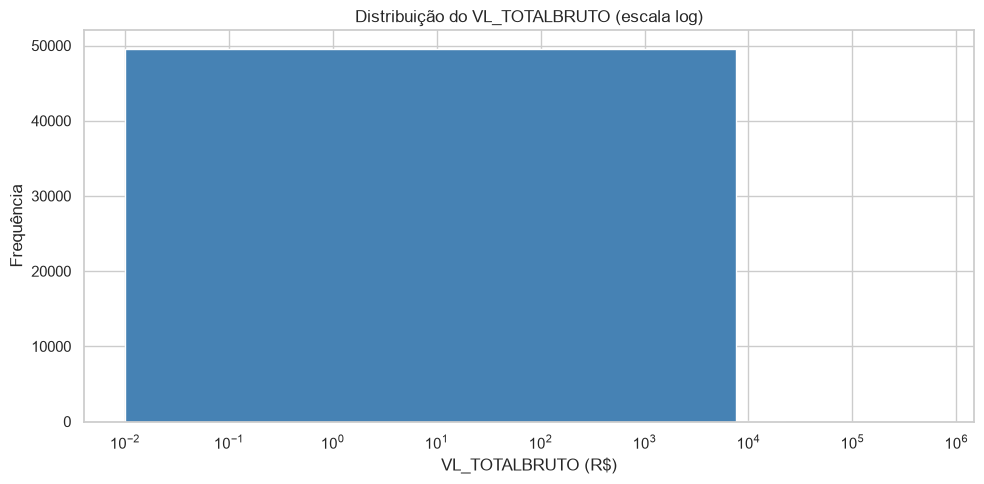

In [33]:
plt.figure(figsize=(10, 5))
plt.hist(df['VL_TOTALBRUTO'][df['VL_TOTALBRUTO'] > 0], bins=80, color='steelblue', edgecolor='white')
plt.xscale('log')
plt.title('Distribuição do VL_TOTALBRUTO (escala log)')
plt.xlabel('VL_TOTALBRUTO (R$)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

### Distribuição da QT_FATURADO

Histograma em escala log no eixo Y para visualizar a concentração de quantidades faturadas, que em sua maioria são iguais a 1.

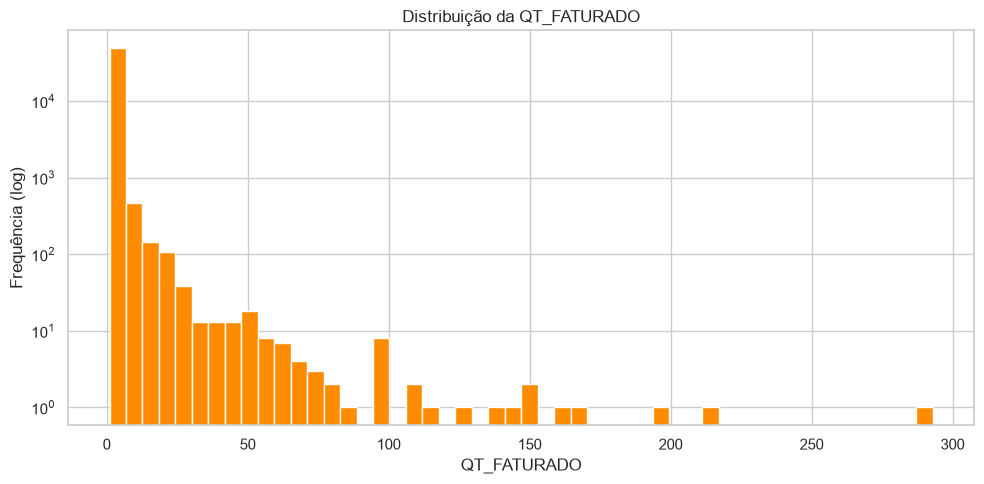

In [34]:
plt.figure(figsize=(10, 5))
plt.hist(df['QT_FATURADO'], bins=50, color='darkorange', edgecolor='white')
plt.yscale('log')
plt.title('Distribuição da QT_FATURADO')
plt.xlabel('QT_FATURADO')
plt.ylabel('Frequência (log)')
plt.tight_layout()
plt.show()

### Boxplot do VL_TOTALBRUTO

Boxplot em escala log para destacar a mediana, os quartis e a grande quantidade de outliers de alto valor.

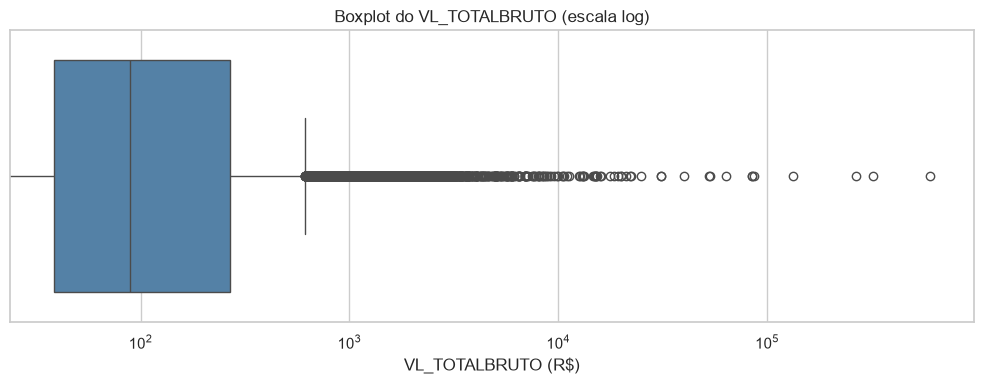

In [35]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['VL_TOTALBRUTO'], color='steelblue')
plt.xscale('log')
plt.title('Boxplot do VL_TOTALBRUTO (escala log)')
plt.xlabel('VL_TOTALBRUTO (R$)')
plt.tight_layout()
plt.show()

### Boxplot da QT_FATURADO

Boxplot para evidenciar os outliers de quantidade faturada, com valores máximos muito acima da mediana (1).

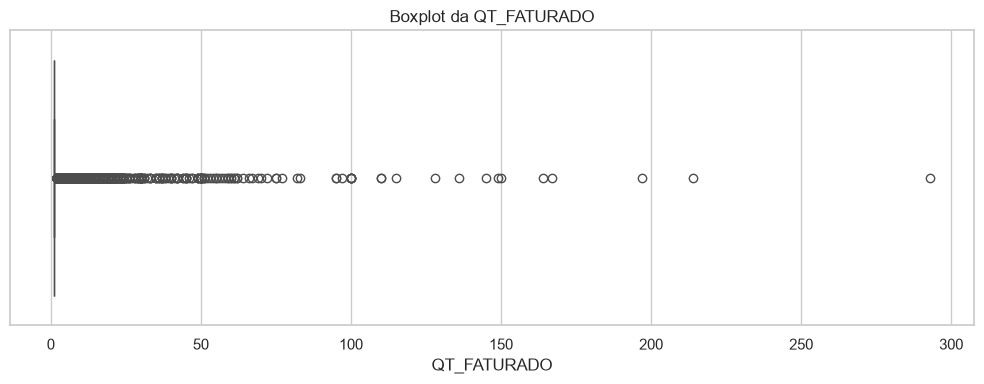

In [36]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['QT_FATURADO'], color='darkorange')
plt.title('Boxplot da QT_FATURADO')
plt.xlabel('QT_FATURADO')
plt.tight_layout()
plt.show()

### Série temporal de faturamento

A coluna `DT_FATURA` já foi convertida para `datetime`. O gráfico abaixo mostra a evolução diária do valor bruto total faturado, permitindo identificar tendências, picos e possíveis sazonalidades no período coberto pela base.

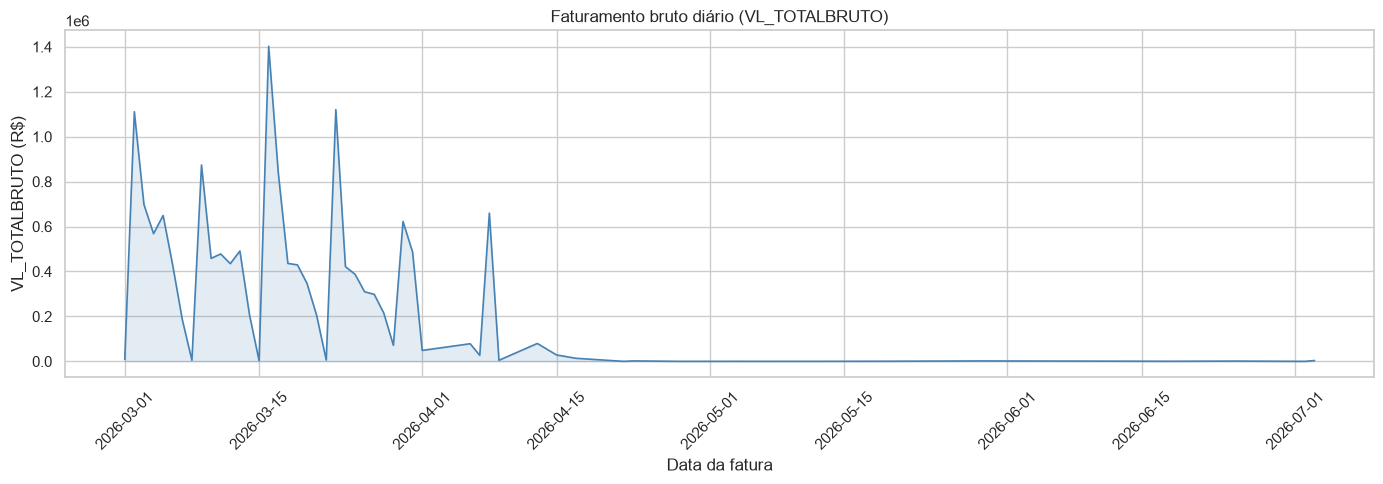

In [37]:
faturamento_diario = df.groupby('DT_FATURA')['VL_TOTALBRUTO'].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(faturamento_diario.index, faturamento_diario.values, color='steelblue', linewidth=1.2)
ax.fill_between(faturamento_diario.index, faturamento_diario.values, alpha=0.15, color='steelblue')
ax.set_title('Faturamento bruto diário (VL_TOTALBRUTO)')
ax.set_xlabel('Data da fatura')
ax.set_ylabel('VL_TOTALBRUTO (R$)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Verificando colunas com prefixo ```CD```

A primeira coisa a ser avaliada é a natureza das colunas com prefixo ```CD``` (Código) para entender melhor do que se trata e quais delas são úteis para o estudo.

In [38]:
cols_cd = [
    'CD_EMPRESA','CD_EMPFAT', 'CD_GRUPOEMPRESA', 'CD_OPERADOR',
    'CD_PRODUTO', 'CD_ESPECIE', 'CD_CST', 'CD_TIPI', 'CD_CFOP',
    ]

for col in cols_cd:
    print(col)
    print(df_raw[col].unique())
    print("="*50,'\n')


CD_EMPRESA
[6]

CD_EMPFAT
[6]

CD_GRUPOEMPRESA
[6]

CD_OPERADOR
[11059 11032 11120   933   831 11159  1161   927  1176  1132  1172 11124
 11118  1148  1180  1138   557   465   939 11134  1173  1129   922   598
 11142 11148  1174   457  1183  1175 11171 11127 11106 11145  1181   468
 11122 11062  1184  1116   589 11139   638]

CD_PRODUTO
[467389 454286 454274 ... 408923 309903 329234]

CD_ESPECIE
<ArrowStringArray>
['UN', 'UM', 'SVC', 'PCT', 'CX', 'JG', 'DZ']
Length: 7, dtype: str

CD_CST
[  0 500 100 200 800 541  41 141 241 841  90  40 600 641 551]

CD_TIPI
<ArrowStringArray>
['63026000', '94049000', '94042100', '63023200', '94042900', '94041000',
 '63022200', '94044000', '39095029', '63021000', '63014000', '63022100',
 '63023900', '63041990', '63023100', '63029100', '63049200', '62064000',
 '63025300', '62034200', '00000000', '61091000', '96190000', '62101000',
 '94039900', '44219900', '94035000', '84248990', '62089200', '63049300',
 '94039100', '94043000', '62092000', '42022900', '85

- As colunas ```CD_EMPRESA```, ```CD_EMPFAT``` e ```CD_GRUPOEMPRESA``` apresentam apenas um único dado, indicando que toda a base de dados é referente à mesma empresa. 

- ```CD_OPERADOR``` indica ser um código interno para referenciar o responsável pela emissão da NF.

- ```CD_PRODUTO``` indica ser um código interno para referenciar o produto da NF.
  
- ```CD_ESPECIE``` indica ser a quantidade ou formato do item. 

- As colunas ```CD_CST```, ```CD_TIPI``` e ```CD_CFOP```, são códigos referentes à natureza contábil do item. 

---

O primeiro passo na análise exploratória vai ser mapear cada código presente nas colunas ```CD_CST```, ```CD_TIPI``` e ```CD_CFOP``` para que seja possível compreender a natureza contábil dos produtos faturados.

### Cardinalidade das colunas com prefixo CD

O gráfico abaixo mostra quantos valores únicos cada coluna com prefixo `CD` possui. Colunas com apenas 1 valor único (como `CD_EMPRESA`, `CD_EMPFAT`, `CD_GRUPOEMPRESA`) não adicionam informação discriminante e podem ser ignoradas na modelagem. Colunas com alta cardinalidade (como `CD_PRODUTO`) indicam identificadores individuais.

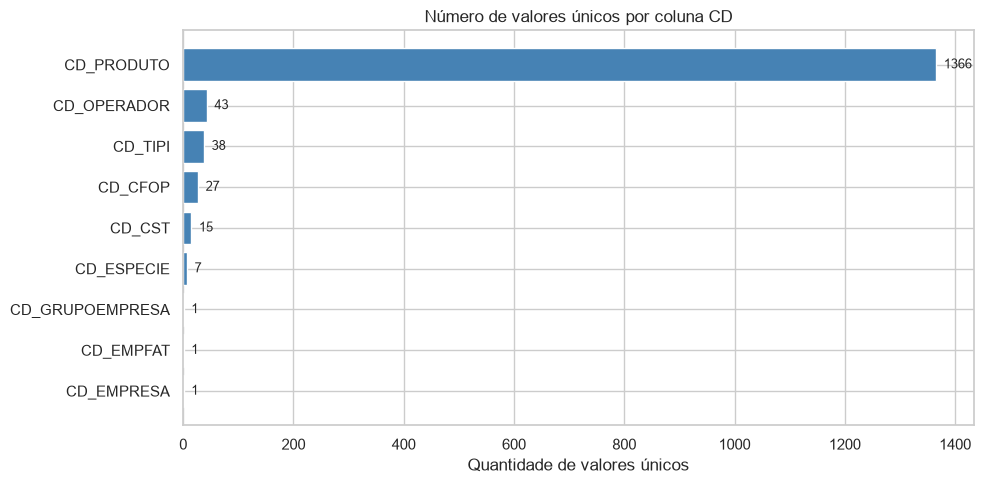

In [39]:
cols_cd = [
    'CD_EMPRESA', 'CD_EMPFAT', 'CD_GRUPOEMPRESA', 'CD_OPERADOR',
    'CD_PRODUTO', 'CD_ESPECIE', 'CD_CST', 'CD_TIPI', 'CD_CFOP',
]

cardinalidade = {col: df[col].nunique() for col in cols_cd}
card_serie = pd.Series(cardinalidade).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(card_serie.index, card_serie.values, color='steelblue', edgecolor='white')
ax.set_title('Número de valores únicos por coluna CD')
ax.set_xlabel('Quantidade de valores únicos')
for bar in bars:
    w = bar.get_width()
    ax.text(w + max(card_serie.values)*0.01, bar.get_y() + bar.get_height()/2,
            str(int(w)), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Mapeando CST

O CST (Código de Situação Tributária) é um código usado nas notas fiscais e no sistema fiscal para indicar como um produto, serviço ou operação está sendo tributado.

De forma simples, ele informa ao fisco coisas como:

- se há cobrança normal de imposto
- se o item é isento
- se tem substituição tributária
- se a operação é imune, suspensa ou não tributada

Em resumo, o CST serve para classificar a situação fiscal da operação, ajudando a preencher corretamente a nota e a apuração dos impostos.

O caso mais comum é o CST do ICMS, que tem 3 dígitos no formato:

- ```A BB```

Onde:

- ```A``` = origem da mercadoria
- ```BB``` = situação tributária do ICMS

Na prática, o primeiro dígito diz de onde vem o produto e os dois últimos dígitos dizem como o imposto será tratado

---

### Tabela da origem da mercadoria

| Código | Origem |
| --- | --- |
| 0 | Nacional, exceto as indicadas nos códigos 3, 4, 5 e 8 |
| 1 | Estrangeira - importação direta |
| 2 | Estrangeira - adquirida no mercado interno |
| 3 | Nacional, mercadoria ou bem com conteúdo de importação superior a 40% e inferior ou igual a 70% |
| 4 | Nacional, cuja produção tenha sido feita em conformidade com os processos produtivos básicos |
| 5 | Nacional, mercadoria ou bem com conteúdo de importação inferior ou igual a 40% |
| 6 | Estrangeira - importação direta, sem similar nacional, constante em lista da CAMEX |
| 7 | Estrangeira - adquirida no mercado interno, sem similar nacional, constante em lista da CAMEX |
| 8 | Nacional, mercadoria ou bem com conteúdo de importação superior a 70% |

### Tabela da situação tributária do ICMS
| Código | Situação tributária |
| --- | --- |
| 00 | Tributada integralmente |
| 10 | Tributada e com cobrança do ICMS por substituição tributária |
| 20 | Com redução de base de cálculo |
| 30 | Isenta ou não tributada e com cobrança do ICMS por substituição tributária |
| 40 | Isenta |
| 41 | Não tributada |
| 50 | Suspensão |
| 51 | Diferimento |
| 60 | ICMS cobrado anteriormente por substituição tributária |
| 70 | Com redução de base de cálculo e cobrança do ICMS por substituição tributária |
| 90 | Outras |

### Exemplo de CST completo
| CST | Significado |
| --- | --- |
| 000 | Mercadoria nacional + tributada integralmente |
| 010 | Mercadoria nacional + tributada com substituição tributária |
| 020 | Mercadoria nacional + redução de base de cálculo |
| 040 | Mercadoria nacional + isenta |
| 060 | Mercadoria nacional + ICMS cobrado anteriormente por ST |
| 100 | Mercadoria estrangeira importada diretamente + tributada integralmente |
| 160 | Mercadoria estrangeira importada diretamente + ICMS cobrado anteriormente por ST |

In [40]:
df['CD_CST'].unique()

array([  0, 500, 100, 200, 800, 541,  41, 141, 241, 841,  90,  40, 600,
       641, 551])

Como o CST tem um padrão de 3 dígitos, e na base há um registro do tipo 0, e outros quatro registros com 2 dígitos. 

Vou inferir que os dígitos faltantes é zero, dessa forma vou adicionar zeros à esquerda para padronizar. 

In [41]:
# Padronizando coluna CD_CST
df['CD_CST'] = df['CD_CST'].astype(str).str.zfill(3)

# Criando indicador para a origem do CST
df['ORIGEM_MERCADORIA'] = df['CD_CST'].str[0]
df['CST_ICMS'] = df['CD_CST'].str[1:]

In [42]:
# Mapeando a origem da mercadoria
origem_map = {
    '0': 'NACIONAL',
    '1': 'ESTRANGEIRA IMPORTACAO DIRETA',
    '2': 'ESTRANGEIRA ADQUIRIDA MERCADO INTERNO',
    '3': 'NACIONAL CONTEUDO IMPORTACAO MAIOR QUE 40PCT MENOR QUE 70PCT',
    '4': 'NACIONAL PROCESSO PRODUTIVO BASICO',
    '5': 'NACIONAL CONTEUDO IMPORTACAO ATE 40PCT',
    '6': 'ESTRANGEIRA IMPORTACAO DIRETA SEM SIMILAR NACIONAL',
    '8': 'NACIONAL CONTEUDO IMPORTACAO MAIOR 70PCT'
}

df['ORIGEM_DESC'] = df['ORIGEM_MERCADORIA'].map(origem_map).fillna('origem_nao_mapeada')


In [43]:
cst_icms_map = {
    '00': 'TRIBUTADO INTEGRALMENTE',
    '40': 'ISENTO',
    '41': 'NAO TRIBUTADO',
    '51': 'DEFERIMENTO',
    '90': 'OUTRAS'
}

df['CST_ICSM_DESC'] = df['CST_ICMS'].map(cst_icms_map).fillna('CST NAO MAPEADO')

#  coluna curta
df['CST_GRUPO'] = df['CST_ICMS'].map({
    '00': 'TRIBUTADO',
    '40': 'ISENTO',
    '41': 'NAO TRIBUTADO',
    '51': 'DEFERIMENTO',
    '90': 'OUTRAS'
}).fillna('NAO MAPEADO')

In [44]:
df.T

In [45]:
# Visualizando resultado das colunas recem criadas

print(df['ORIGEM_MERCADORIA'].value_counts(normalize=True).mul(100), "\n")
print(df['ORIGEM_DESC'].value_counts(normalize=True).mul(100), "\n")
print(df['CST_ICMS'].value_counts(normalize=True).mul(100), "\n")
print(df['CST_ICSM_DESC'].value_counts(normalize=True).mul(100), "\n")

ORIGEM_MERCADORIA
0    59.981054
5    38.194864
1     1.678962
2     0.131011
8     0.010078
6     0.004031
Name: proportion, dtype: float64 

ORIGEM_DESC
NACIONAL                                              59.981054
NACIONAL CONTEUDO IMPORTACAO ATE 40PCT                38.194864
ESTRANGEIRA IMPORTACAO DIRETA                          1.678962
ESTRANGEIRA ADQUIRIDA MERCADO INTERNO                  0.131011
NACIONAL CONTEUDO IMPORTACAO MAIOR 70PCT               0.010078
ESTRANGEIRA IMPORTACAO DIRETA SEM SIMILAR NACIONAL     0.004031
Name: proportion, dtype: float64 

CST_ICMS
00    76.952070
41    16.962954
40     6.060789
90     0.020156
51     0.004031
Name: proportion, dtype: float64 

CST_ICSM_DESC
TRIBUTADO INTEGRALMENTE    76.952070
NAO TRIBUTADO              16.962954
ISENTO                      6.060789
OUTRAS                      0.020156
DEFERIMENTO                 0.004031
Name: proportion, dtype: float64 



- A maioria das mercadorias da base são de origem nacional, menos de 2% são itens importados.

- Aproximadamente 77% dos itens ocorre tributação integral enquanto 

- Aproximadamente 17% não é tributado.  

- 6% dos itens são isentos de tributação.

### Distribuição da Origem da Mercadoria

Gráfico de barras horizontais mostrando a predominância de mercadorias nacionais frente às importadas, conforme os percentuais descritos na análise.

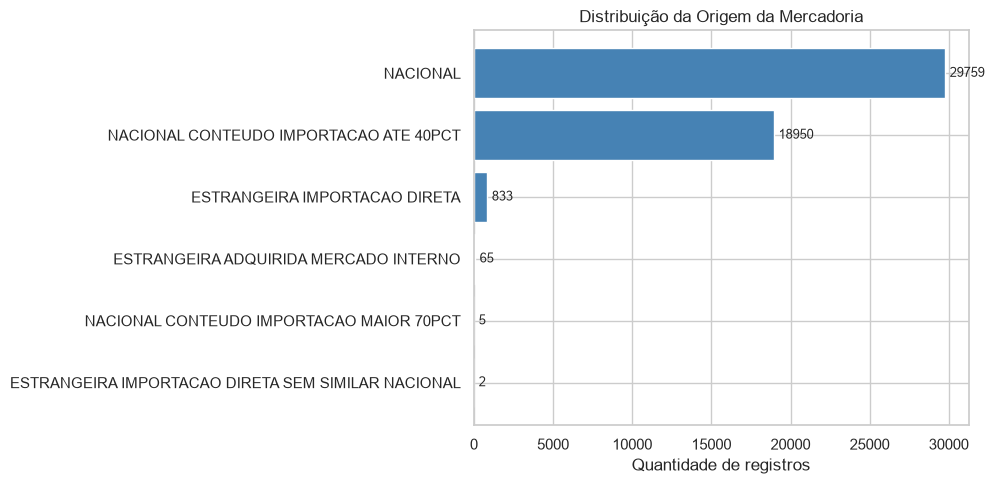

In [46]:
origem_counts = df['ORIGEM_DESC'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.barh(origem_counts.index[::-1], origem_counts.values[::-1], color='steelblue', edgecolor='white')
plt.title('Distribuição da Origem da Mercadoria')
plt.xlabel('Quantidade de registros')
for i, v in enumerate(origem_counts.values[::-1]):
    plt.text(v + max(origem_counts.values)*0.01, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Distribuição do Grupo de Tributação (CST_ICMS)

Gráfico de barras horizontais evidenciando que aproximadamente 77% dos itens são tributados integralmente, ~17% não tributados e ~6% isentos.

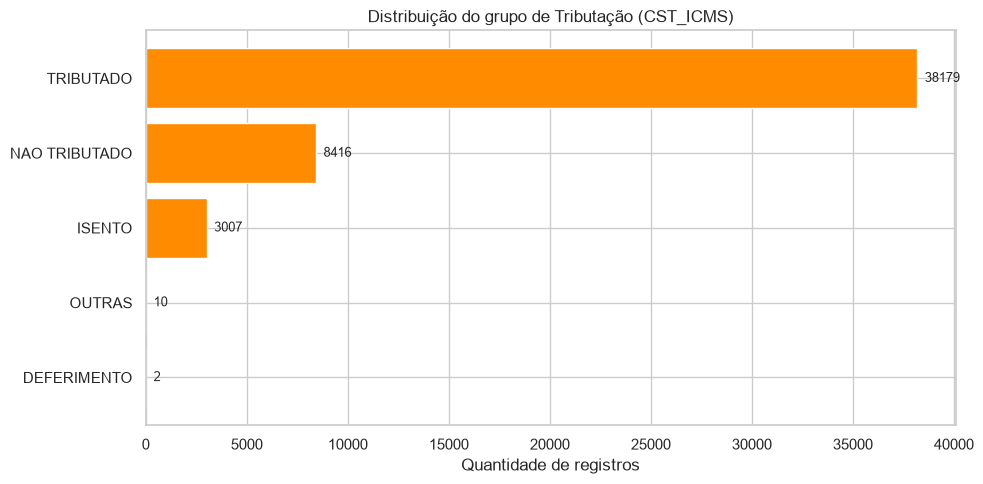

In [47]:
cst_counts = df['CST_GRUPO'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.barh(cst_counts.index[::-1], cst_counts.values[::-1], color='darkorange', edgecolor='white')
plt.title('Distribuição do grupo de Tributação (CST_ICMS)')
plt.xlabel('Quantidade de registros')
for i, v in enumerate(cst_counts.values[::-1]):
    plt.text(v + max(cst_counts.values)*0.01, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Mapeando CFOP

O CFOP (Código Fiscal de Operações e Prestações) é o código usado para identificar a natureza de uma entrada ou saída de mercadoria, bem ou serviço em uma operação fiscal.

Em termos práticos, ele informa o que está acontecendo na operação do ponto de vista fiscal. Enquanto o CST mostra como o tributo é tratado, o CFOP mostra qual é o tipo de operação realizada, como por exemplo: compra, venda, devolução, transferência, remessa, retorno, exportação ou importação.

O CFOP serve para classificar operações como:

- Compra de mercadoria
- Venda de produto
- Transferência entre filiais
- Devolução de compra ou venda
- Remessa para conserto, industrialização ou demonstração
- Retorno de mercadoria
- Importação e exportação
- Prestações de serviço de transporte e comunicação

Ele é essencial porque impacta:

- Emissão correta da nota fiscal
- Escrituração fiscal
- Apuração de tributos
- Entrega de obrigações acessórias

--- 

### Formato / padrão do CFOP
O CFOP tem 4 dígitos numéricos.

Estrutura

- ```XYYY```

Onde:

- ```X``` = indica o tipo geral da operação
- ```YYY``` = identifica a natureza específica da operação

#### Significado do 1º dígito

| 1º dígito | Tipo de operação |
| --- | --- |
| 1 | Entrada ou aquisição dentro do estado |
| 2 | Entrada ou aquisição de outro estado |
| 3 | Entrada ou aquisição do exterior |
| 5 | Saída ou prestação dentro do estado |
| 6 | Saída ou prestação para outro estado |
| 7 | Saída ou prestação para o exterior |

#### Leitura prática do código

Exemplo: 5102

- 5 = saída dentro do estado
- 102 = venda de mercadoria adquirida ou recebida de terceiros

Ou seja, o CFOP 5102 significa:

- Venda de mercadoria adquirida ou recebida de terceiros, dentro do estado

Outro exemplo: 2102

- 2 = entrada de outro estado
- 102 = compra para comercialização

Ou seja:

- Compra para comercialização, vinda de outro estado

---

In [48]:
df['CD_CFOP'].unique()

<ArrowStringArray>
['6106', '2907', '6108', '5102', '6102', '2202', '5152', '1202', '1152',
 '1933', '6905', '6910', '5949', '1556', '5106', '6949', '2906', '2353',
 '1353', '5910', '2933', '2949', '2910', '1551', '2556', '6152', '1949']
Length: 27, dtype: str

### Descrição dos códigos CFOP da base de dados

| CFOP | Descrição resumida |
| --- | --- |
| 6106 | Venda de mercadoria adquirida ou recebida de terceiros, que não deve transitar pelo estabelecimento |
| 2907 | Retorno simbólico de mercadoria remetida para depósito fechado ou armazém geral |
| 6108 | Venda de mercadoria adquirida ou recebida de terceiros, destinada a não contribuinte |
| 5102 | Venda de mercadoria adquirida ou recebida de terceiros |
| 6102 | Venda de mercadoria adquirida ou recebida de terceiros, para outro estado |
| 2202 | Devolução de venda de mercadoria adquirida ou recebida de terceiros, de outro estado |
| 5152 | Transferência de mercadoria adquirida ou recebida de terceiros |
| 1202 | Devolução de venda de mercadoria adquirida ou recebida de terceiros, dentro do estado |
| 1152 | Transferência recebida para comercialização |
| 1933 | Aquisição de serviço tributado pelo ISSQN |
| 6905 | Remessa para depósito fechado ou armazém geral |
| 6910 | Remessa em bonificação, doação ou brinde |
| 5949 | Outra saída de mercadoria ou prestação de serviço não especificado |
| 1556 | Compra de material para uso ou consumo |
| 5106 | Venda de mercadoria adquirida ou recebida de terceiros, que não deve transitar pelo estabelecimento |
| 6949 | Outra saída de mercadoria ou prestação de serviço não especificado, para outro estado |
| 2906 | Retorno de mercadoria remetida para depósito fechado ou armazém geral |
| 2353 | Aquisição de serviço de transporte por estabelecimento comercial, de outro estado |
| 1353 | Aquisição de serviço de transporte por estabelecimento comercial |
| 5910 | Remessa em bonificação, doação ou brinde |
| 2933 | Aquisição de serviço tributado pelo ISSQN, de outro estado |
| 2949 | Outra entrada de mercadoria ou prestação de serviço não especificado, de outro estado |
| 2910 | Entrada de mercadoria recebida em bonificação, doação ou brinde, de outro estado |
| 1551 | Compra de bem para o ativo imobilizado |
| 2556 | Compra de material para uso ou consumo, de outro estado |
| 6152 | Transferência de mercadoria adquirida ou recebida de terceiros, para outro estado |
| 1949 | Outra entrada de mercadoria ou prestação de serviço não especificado |

In [49]:
# Quebrando o código
df['CFOP_PREFIXO'] = df['CD_CFOP'].str[0]
df['CFOP_GRUPO_BASE'] = df['CD_CFOP'].str[1:]

# Mapeando o fluxo
MAPA_CFOP_TIPO_FLUXO = {
    '1': 'ENTRADA',
    '2': 'ENTRADA',
    '3': 'ENTRADA',
    '5': 'SAIDA',
    '6': 'SAIDA',
    '7': 'SAIDA'
}

df['CFOP_TIPO_FLUXO'] = df['CFOP_PREFIXO'].map(MAPA_CFOP_TIPO_FLUXO).fillna('NAO MAPEADO')

# Mapeando abrangencia
MAPA_CFOP_ABRANGENCIA = {
    '1': 'INTERNA',
    '2': 'INTERESTADUAL',
    '3': 'EXTERIOR',
    '5': 'INTERNA',
    '6': 'INTERESTADUAL',
    '7': 'EXTERIOR'
}

df['CFOP_ABRANGENCIA'] = df['CFOP_PREFIXO'].map(MAPA_CFOP_ABRANGENCIA).fillna('NAO MAPEADO')

# Classe Geral Combinada
df['CFOP_CLASSE_GERAL'] = df['CFOP_TIPO_FLUXO'] + ' ' + df['CFOP_ABRANGENCIA']

In [50]:
# Validando colunas criadas
df[['CD_CFOP', 'CFOP_PREFIXO', 'CFOP_GRUPO_BASE', 'CFOP_TIPO_FLUXO', 'CFOP_ABRANGENCIA', 'CFOP_CLASSE_GERAL']].drop_duplicates().sort_values('CD_CFOP')

In [51]:
df['CFOP_GRUPO_BASE'].unique()

<ArrowStringArray>
['106', '907', '108', '102', '202', '152', '933', '905', '910', '949', '556',
 '906', '353', '551']
Length: 14, dtype: str

### Descricao dos Grupo Base do CFOP 
| Sufixo | Grupo-base / ideia central | Leitura prática | Exemplos comuns |
| --- | --- | --- | --- |
| 106 | Mercadoria adquirida ou recebida de terceiros sem trânsito pelo estabelecimento | Operação de compra/venda em que a mercadoria não passa fisicamente pelo emitente | 5106, 6106 |
| 907 | Retorno simbólico de mercadoria remetida para depósito fechado ou armazém geral | Registro fiscal de retorno, sem necessariamente haver retorno físico naquele momento | 1907, 2907 |
| 108 | Mercadoria adquirida ou recebida de terceiros destinada a não contribuinte | Muito comum em venda para consumidor final não contribuinte | 5108, 6108 |
| 102 | Mercadoria adquirida ou recebida de terceiros para comercialização | É um dos grupos mais comuns: compra para revenda ou venda de mercadoria comprada de terceiros | 1102, 2102, 5102, 6102 |
| 202 | Devoluções ligadas a mercadoria adquirida ou recebida de terceiros | Em entradas, costuma indicar devolução de venda; em saídas, devolução de compra | 1202, 2202, 5202, 6202 |
| 152 | Transferência de mercadoria adquirida ou recebida de terceiros | Movimentação entre estabelecimentos, sem caracterizar venda | 1152, 2152, 5152, 6152 |
| 933 | Serviço tributado pelo ISSQN | Normalmente usado para aquisição/lançamento de serviço sujeito ao ISS | 1933, 2933 |
| 905 | Operação com depósito fechado ou armazém geral | Família ligada à remessa/entrada para depósito | 1905, 2905, 5905, 6905 |
| 910 | Bonificação, doação ou brinde | Entrada ou remessa de mercadoria sem caráter normal de venda | 1910, 2910, 5910, 6910 |
| 949 | Outras entradas/saídas não especificadas | Grupo genérico, usado quando a operação não se encaixa em código mais específico | 1949, 2949, 5949, 6949 |
| 556 | Material para uso ou consumo | Compra de itens que serão consumidos internamente pela empresa | 1556, 2556 |
| 906 | Retorno físico de mercadoria remetida para depósito fechado ou armazém geral | Diferente do 907, aqui há retorno efetivo da mercadoria | 1906, 2906 |
| 353 | Aquisição de serviço de transporte por estabelecimento comercial | Grupo ligado à contratação de frete/transporte | 1353, 2353 |
| 551 | Bem para o ativo imobilizado | Compra de bens duráveis para uso da empresa, como máquinas, móveis, equipamentos | 1551, 2551 |

In [52]:
# Mapeando o tipo da operação pelo grupo-base do CFOP
MAPA_CFOP_TIPO_OPERACAO = {
    '102': 'VENDA',
    '106': 'VENDA SEM TRANSITO',
    '108': 'VENDA CONSUMIDOR FINAL',
    '152': 'TRANSFERENCIA',
    '202': 'DEVOLUCAO',
    '353': 'AQUISICAO SERVICO TRANSPORTE',
    '551': 'ATIVO IMOBILIZADO',
    '556': 'USO CONSUMO',
    '905': 'OPERACAO DEPOSITO ARMAZEM_GERAL',
    '906': 'RETORNO DEPOSITO ARMAZEM_GERAL',
    '907': 'RETORNO SIMBOLICO DEPOSITO ARMAZEM_GERAL',
    '910': 'BONIFICACAO DOACAO BRINDE',
    '933': 'AQUISICAO SERVICO ISSQN',
    '949': 'OUTRA OPERACAO',
}

df['CFOP_TIPO_OPERACAO'] = (
    df['CFOP_GRUPO_BASE']
    .astype(str)
    .map(MAPA_CFOP_TIPO_OPERACAO)
    .fillna('NAO MAPEADO')
)

In [53]:
print(df['CFOP_PREFIXO'].value_counts(normalize=True).sort_index().mul(100), '\n')
print(df['CFOP_TIPO_FLUXO'].value_counts(normalize=True).mul(100), '\n')
print(df['CFOP_ABRANGENCIA'].value_counts(normalize=True).mul(100), '\n')

CFOP_PREFIXO
1    24.575725
2    27.113315
5     6.080945
6    42.230016
Name: proportion, dtype: float64 

CFOP_TIPO_FLUXO
ENTRADA    51.689039
SAIDA      48.310961
Name: proportion, dtype: float64 

CFOP_ABRANGENCIA
INTERESTADUAL    69.343331
INTERNA          30.656669
Name: proportion, dtype: float64 



In [54]:
print(df['CFOP_CLASSE_GERAL'].value_counts(normalize=True).mul(100), '\n')

CFOP_CLASSE_GERAL
SAIDA INTERESTADUAL      42.230016
ENTRADA INTERESTADUAL    27.113315
ENTRADA INTERNA          24.575725
SAIDA INTERNA             6.080945
Name: proportion, dtype: float64 



In [55]:
print(df['CFOP_TIPO_OPERACAO'].value_counts(normalize=True).mul(100), '\n')

CFOP_TIPO_OPERACAO
VENDA CONSUMIDOR FINAL                      40.248720
AQUISICAO SERVICO TRANSPORTE                33.430080
TRANSFERENCIA                               16.928689
VENDA                                        3.422421
DEVOLUCAO                                    2.727053
RETORNO SIMBOLICO DEPOSITO ARMAZEM_GERAL     1.128714
VENDA SEM TRANSITO                           1.124683
AQUISICAO SERVICO ISSQN                      0.433345
BONIFICACAO DOACAO BRINDE                    0.364816
OPERACAO DEPOSITO ARMAZEM_GERAL              0.108840
OUTRA OPERACAO                               0.036280
RETORNO DEPOSITO ARMAZEM_GERAL               0.028218
USO CONSUMO                                  0.014109
ATIVO IMOBILIZADO                            0.004031
Name: proportion, dtype: float64 



In [56]:
pd.crosstab(df['CFOP_TIPO_OPERACAO'], df['CFOP_TIPO_FLUXO'], normalize='index').sort_values(by='SAIDA').round(4).mul(100)

In [57]:
pd.crosstab(df['CFOP_TIPO_OPERACAO'], df['CFOP_ABRANGENCIA'], normalize='index').sort_values(by='INTERESTADUAL').round(4).mul(100)

In [58]:
pd.crosstab(df['CFOP_TIPO_OPERACAO'], df['CFOP_CLASSE_GERAL'], normalize='index').round(4).mul(100)

#### Panorama geral

A distribuição de CFOP_CLASSE_GERAL mostra:

- SAIDA INTERESTADUAL: 42.23%
- ENTRADA INTERESTADUAL: 27.11%
- ENTRADA INTERNA: 24.58%
- SAIDA INTERNA: 6.08%

A leitura das informações obtidas atraves do CFOP são:

- A operação é fortemente interestadual
- Há predomínio de saídas sobre entradas
- A dinâmica do negócio é mais voltada para expedição/venda para fora do estado do que para circulação local

Consolindando os valores

- Interestadual Total = 42.23 + 27.11 = 69.34%
- Interna Total = 24.58 + 6.08 = 30.66%

O resultado de CFOP_TIPO_OPERACAO também parece coerente

Os maiores blocos foram:

- VENDA CONSUMIDOR FINAL: 40.25%
- AQUISICAO SERVICO TRANSPORTE: 33.43%
- TRANSFERENCIA: 16.93%
- VENDA: 3.42%
- DEVOLUCAO: 2.73%

Isso sugere uma operação com este perfil:

- Muita venda interestadual para não contribuinte
- Muito lançamento de frete / serviço de transporte
- Volume relevante de transferência
- Devoluções em nível moderado
- Pouca participação relativa de ativo, uso/consumo e outras operações

Ao cruzar o tipo de operação com a classe geral e também abrangência, o tipo TRANSFERENCIA revela uma assimetria interessante.

Representando 16,93% dos registros, a distribuição ficou:

- 82.15% ENTRADA
- 17.85% SAIDA
- 99.98% INTERNA

Esse resultado sugere um padrão muito específico:

- A unidade analisada parece receber muito mais transferência do que enviar
- Isso acontece quase sempre dentro do estado

Essa leitura lembra um estabelecimento que atua como:

- Ponto receptor de estoque
- Central de distribuição local
- Filial abastecida por outra unidade
- Unidade operacional que recebe mercadoria para execução local

---

### Distribuição CFOP_CLASSE_GERAL

Barras horizontais mostrando a composição entre entrada/saída e interna/interestadual, reforçando o caráter interestadual da operação.

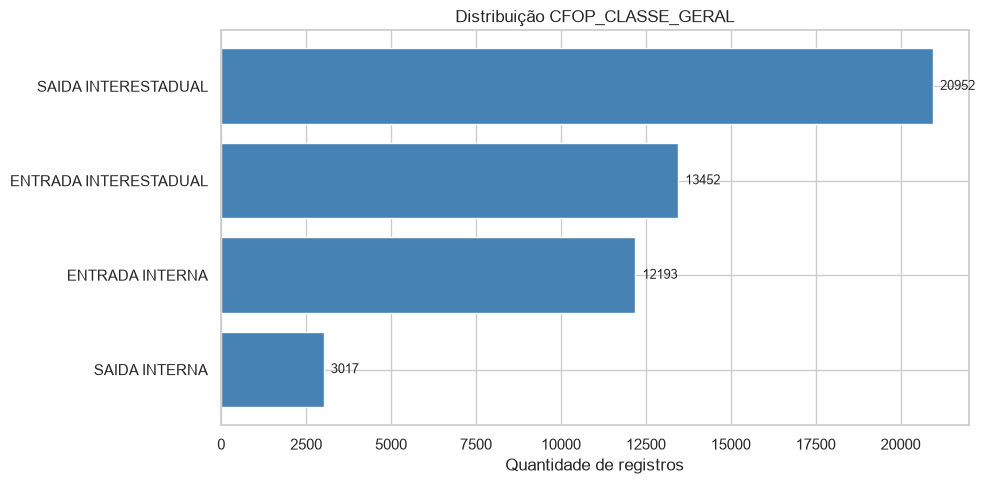

In [59]:
classe_counts = df['CFOP_CLASSE_GERAL'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.barh(classe_counts.index[::-1], classe_counts.values[::-1], color='steelblue', edgecolor='white')
plt.title('Distribuição CFOP_CLASSE_GERAL')
plt.xlabel('Quantidade de registros')
for i, v in enumerate(classe_counts.values[::-1]):
    plt.text(v + max(classe_counts.values)*0.01, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Distribuição CFOP_TIPO_OPERACAO

Ranking dos tipos de operação, evidenciando `VENDA CONSUMIDOR FINAL` e `AQUISICAO SERVICO TRANSPORTE` como os maiores blocos.

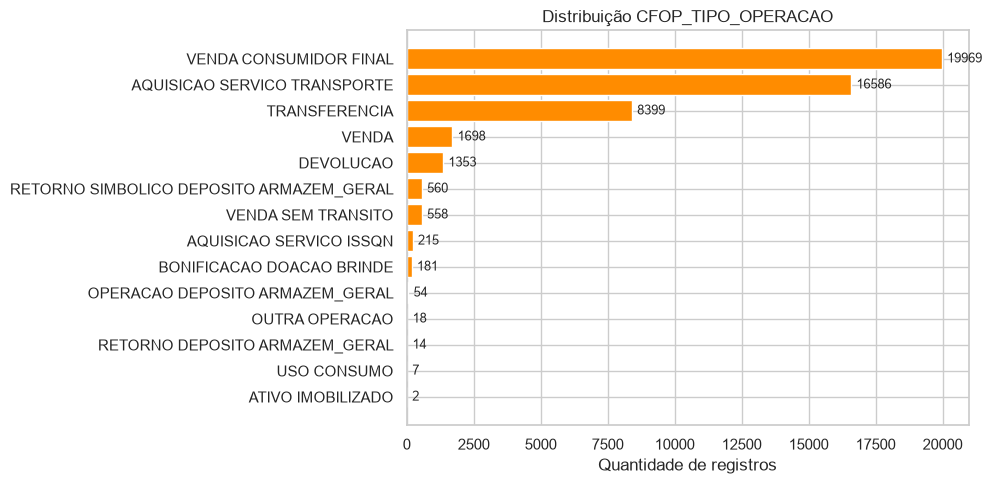

In [60]:
tipo_counts = df['CFOP_TIPO_OPERACAO'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.barh(tipo_counts.index[::-1], tipo_counts.values[::-1], color='darkorange', edgecolor='white')
plt.title('Distribuição CFOP_TIPO_OPERACAO')
plt.xlabel('Quantidade de registros')
for i, v in enumerate(tipo_counts.values[::-1]):
    plt.text(v + max(tipo_counts.values)*0.01, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

#### Cruzamento CFOP_TIPO_OPERACAO x CFOP_ABRANGENCIA

O heatmap abaixo visualiza a percentages dentro de cada tipo de operação, evidenciando a assimetria identificada na análise textual — por exemplo, Transferência é quase totalmente interna (99,98%).

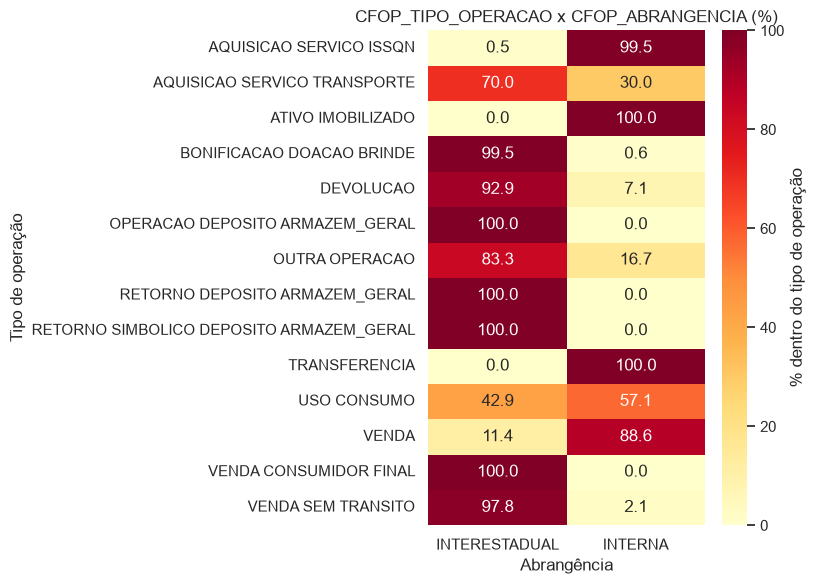

In [61]:
ct = pd.crosstab(df['CFOP_TIPO_OPERACAO'], df['CFOP_ABRANGENCIA'],
                normalize='index').mul(100).round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': '% dentro do tipo de operação'})
ax.set_title('CFOP_TIPO_OPERACAO x CFOP_ABRANGENCIA (%)')
ax.set_xlabel('Abrangência')
ax.set_ylabel('Tipo de operação')
plt.tight_layout()
plt.show()

## Mapeando TIPI

A TIPI é a Tabela de Incidência do Imposto sobre Produtos Industrializados (IPI).

De forma simples, ela é a tabela oficial usada para classificar mercadorias e para determinar a alíquota de IPI aplicável a cada produto. No CFOP foi identificado a natureza da operação, e no CST tributária, na TIPI você olha para o produto em si: o que ele é, em qual classificação fiscal ele se encaixa e qual tributação de IPI pode incidir sobre ele.

#### O que é a TIPI na prática
A
 TIPI organiza os produtos em uma estrutura padronizada de classificação fiscal. Essa estrutura segue a lógica da NCM/SH:

- SH = Sistema Harmonizado
- NCM = Nomenclatura Comum do Mercosul
- TIPI = tabela que usa essa classificação para fins de IPI

Ou seja, na prática, a TIPI é uma tabela que pega os códigos da NCM e informa a respectiva tributação de IPI, além de notas e desdobramentos legais quando aplicáveis.

#### Para que serve a TIPI

A TIPI serve principalmente para:

- Classificar fiscalmente o produto
- Identificar a alíquota do IPI
- Padronizar o enquadramento de mercadorias
- Apoiar a emissão correta de nota fiscal
- Dar base para apuração tributária e obrigações acessórias

Em outras palavras, ela ajuda a responder:

- Que produto é esse, fiscalmente falando?
- Em qual código ele se enquadra?
- Qual alíquota de IPI pode incidir sobre ele?

#### Relação entre TIPI, NCM e IPI

Esse é o ponto mais importante para não confundir os conceitos.

- NCM é o código de classificação da mercadoria.
- TIPI é a tabela que organiza essas classificações e associa a elas a incidência do IPI.
- O IPI é o imposto cuja incidência é definida com base nessa tabela.

Então a relação é:

- NCM = código do produto
- TIPI = tabela oficial que usa esse código para enquadrar o produto
- IPI = imposto calculado conforme esse enquadramento
- Na prática, muita gente fala “código TIPI”, mas frequentemente está se referindo ao próprio código NCM do produto dentro da estrutura da TIPI.

#### Como é a estrutura da TIPI

A TIPI segue uma estrutura hierárquica de classificação. Essa hierarquia vem do Sistema Harmonizado e da NCM.

Estrutura geral

| Nível | Descrição |
| --- | --- |
| Seção | Agrupa grandes conjuntos de mercadorias |
| Capítulo | Agrupa famílias amplas de produtos |
| Posição | Subgrupo dentro do capítulo |
| Subposição | Detalhamento da posição |
| Item | Detalhamento adicional |
| Subitem | Nível mais específico da NCM |

Na prática, o código mais usado no dia a dia é o da NCM com 8 dígitos.

#### Formato / padrão do código

A classificação normalmente aparece no padrão da NCM, com 8 dígitos:

- ```XX.XX.XX.XX```

Ou sem pontuação:

- ```XXXXXXXX```

Exemplo de leitura estrutural:

- 2 primeiros dígitos = capítulo
- 4 primeiros = posição
- 6 primeiros = subposição
- 7º dígito = item
- 8º dígito = subitem



In [62]:
df['CD_TIPI'].unique()

<ArrowStringArray>
['63026000', '94049000', '94042100', '63023200', '94042900', '94041000',
 '63022200', '94044000', '39095029', '63021000', '63014000', '63022100',
 '63023900', '63041990', '63023100', '63029100', '63049200', '62064000',
 '63025300', '62034200', '00000000', '61091000', '96190000', '62101000',
 '94039900', '44219900', '94035000', '84248990', '62089200', '63049300',
 '94039100', '94043000', '62092000', '42022900', '85429000', '84715010',
 '62033200', '85171300']
Length: 38, dtype: str

In [63]:
# Separando o código pela estrutura
df['TIPI_CAPITULO'] = df['CD_TIPI'].str[:2]
df['TIPI_POSICAO'] = df['CD_TIPI'].str[:4]
df['TIPI_SUBPOSICAO'] = df['CD_TIPI'].str[:6]
df['TIPI_ITEM'] = df['CD_TIPI']

In [64]:
cols_tipi = ['TIPI_CAPITULO', 'TIPI_POSICAO', 'TIPI_SUBPOSICAO']

for col in cols_tipi:
    print(col)
    print(df[col].unique())
    print("="*50,'\n')

TIPI_CAPITULO
<ArrowStringArray>
['63', '94', '39', '62', '00', '61', '96', '44', '84', '42', '85']
Length: 11, dtype: str

TIPI_POSICAO
<ArrowStringArray>
['6302', '9404', '3909', '6301', '6304', '6206', '6203', '0000', '6109',
 '9619', '6210', '9403', '4421', '8424', '6208', '6209', '4202', '8542',
 '8471', '8517']
Length: 20, dtype: str

TIPI_SUBPOSICAO
<ArrowStringArray>
['630260', '940490', '940421', '630232', '940429', '940410', '630222',
 '940440', '390950', '630210', '630140', '630221', '630239', '630419',
 '630231', '630291', '630492', '620640', '630253', '620342', '000000',
 '610910', '961900', '621010', '940399', '442199', '940350', '842489',
 '620892', '630493', '940391', '940430', '620920', '420229', '854290',
 '847150', '620332', '851713']
Length: 38, dtype: str



### Descrição dos capítulos do TIPI

| Capítulo | Nome | Descrição |
| --- | --- | --- |
| 00 | Não classificado | Valor genérico ou item sem enquadramento fiscal válido. |
| 39 | Plásticos e suas obras | Inclui matérias plásticas e seus artefatos, como embalagens, recipientes, chapas, filmes, tubos e outros produtos de plástico. |
| 42 | Obras de couro e artigos semelhantes | Abrange artigos de couro, bolsas, mochilas, malas, carteiras, artigos de viagem e artefatos semelhantes. |
| 44 | Madeira, carvão vegetal e obras de madeira | Inclui madeira bruta ou beneficiada, painéis, pallets, embalagens, molduras e demais artefatos de madeira. |
| 61 | Vestuário e acessórios de malha | Reúne roupas e acessórios confeccionados em malha, como camisetas, roupas íntimas, meias e peças similares. |
| 62 | Vestuário e acessórios, exceto de malha | Engloba roupas e acessórios confeccionados em tecido plano ou outros materiais que não sejam malha, como camisas, calças, jaquetas e uniformes. |
| 63 | Outros artefatos têxteis confeccionados | Inclui roupa de cama, mesa e banho, cortinas, sacarias, panos de limpeza e outros têxteis confeccionados. |
| 84 | Máquinas e aparelhos mecânicos | Capítulo amplo que abrange máquinas, equipamentos, aparelhos mecânicos, instrumentos e suas partes. |
| 85 | Máquinas, aparelhos e materiais elétricos | Inclui equipamentos elétricos e eletrônicos, motores, cabos, aparelhos de som/imagem e componentes relacionados. |
| 94 | Móveis, iluminação e construções pré-fabricadas | Abrange móveis, colchões, almofadas, luminárias, mobiliário médico-cirúrgico e construções pré-fabricadas. |
| 96 | Obras diversas | Capítulo residual com diversos produtos manufaturados, como escovas, botões, canetas, isqueiros, zíperes e outros itens variados. |

In [65]:
MAPA_TIPI_GRUPO_FISCAL = {
    '00': 'SEM CLASSIFICACAO',
    '39': 'QUIMICOS E PLASTICOS',
    '42': 'ACESSORIOS E BOLSAS',
    '44': 'MADEIRA',
    '61': 'VESTUARIO DE MALHA',
    '62': 'VESTUARIO DE TECIDO',
    '63': 'CAMA MESA BANHO',
    '84': 'MAQUINAS E APARELHOS',
    '85': 'ELETRONICOS E TELECOM',
    '94': 'MOVEIS E COLCHOES',
    '96': 'HIGIENE'
}

df['TIPI_GRUPO_FISCAL'] = (
    df['TIPI_CAPITULO']
    .map(MAPA_TIPI_GRUPO_FISCAL)
    .fillna('NAO MAPEADO')
)

In [66]:
MAPA_TIPI_TIPO_PRODUTO = {
    '00000000': 'SEM CLASSIFICACAO',
    '39095029': 'POLIURETANOS',
    '42022900': 'BOLSAS E SEMELHANTES',
    '44219900': 'ARTEFATOS DE MADEIRA',
    '61091000': 'CAMISETAS ALGODAO',
    '62033200': 'BLAZERS MASCULINOS ALGODAO',
    '62034200': 'CALCAS MASCULINAS ALGODAO',
    '62064000': 'BLUSAS FEMININAS SINTETICAS',
    '62089200': 'ROUPA INTIMA FEMININA SINTETICA',
    '62092000': 'VESTUARIO PARA BEBES ALGODAO',
    '62101000': 'VESTUARIO TECNICO',
    '63014000': 'COBERTORES E MANTAS SINTETICAS',
    '63021000': 'ROUPA DE CAMA DE MALHA',
    '63022100': 'ROUPA DE CAMA ESTAMPADA ALGODAO',
    '63022200': 'ROUPA DE CAMA ESTAMPADA SINTETICA',
    '63023100': 'ROUPA DE CAMA ALGODAO',
    '63023200': 'ROUPA DE CAMA FIBRAS SINTETICAS',
    '63023900': 'OUTRAS ROUPAS DE CAMA',
    '63025300': 'ROUPAS DE MESA SINTETICAS',
    '63026000': 'TOALHAS DE ALGODAO',
    '63029100': 'TOALHAS E ARTEFATOS DE ALGODAO',
    '63041990': 'COLCHAS E COBRE LEITOS',
    '63049200': 'ARTIGOS DE DECORACAO ALGODAO',
    '63049300': 'ARTIGOS DE DECORACAO SINTETICOS',
    '84248990': 'APARELHOS PARA PULVERIZAR',
    '84715010': 'UNIDADE DE PROCESSAMENTO DIGITAL',
    '85171300': 'SMARTPHONES',
    '85429000': 'PARTES DE CIRCUITOS INTEGRADOS',
    '94035000': 'MOVEIS DE MADEIRA PARA QUARTO',
    '94039100': 'PARTES DE MOVEIS DE MADEIRA',
    '94039900': 'PARTES DE MOVEIS',
    '94041000': 'SUPORTE PARA COLCHAO',
    '94042100': 'COLCHOES ESPUMA OU BORRACHA',
    '94042900': 'OUTROS COLCHOES',
    '94043000': 'SACOS DE DORMIR',
    '94044000': 'EDREDONS TRAVESSEIROS E ALMOFADAS',
    '94049000': 'ARTIGOS DE CAMA',
    '96190000': 'ARTIGOS HIGIENICOS'
}

df['TIPI_TIPO_PRODUTO'] = (
    df['CD_TIPI']
    .map(MAPA_TIPI_TIPO_PRODUTO)
    .fillna('NAO MAPEADO')
)


In [67]:
MAPA_TIPI_FAMILIA_COMERCIAL = {
    '00000000': 'SEM CLASSIFICACAO',
    '39095029': 'INSUMOS',
    '42022900': 'ACESSORIOS',
    '44219900': 'MADEIRA',
    '61091000': 'VESTUARIO',
    '62033200': 'VESTUARIO',
    '62034200': 'VESTUARIO',
    '62064000': 'VESTUARIO',
    '62089200': 'VESTUARIO',
    '62092000': 'VESTUARIO INFANTIL',
    '62101000': 'VESTUARIO',
    '63014000': 'CAMA',
    '63021000': 'CAMA',
    '63022100': 'CAMA',
    '63022200': 'CAMA',
    '63023100': 'CAMA',
    '63023200': 'CAMA',
    '63023900': 'CAMA',
    '63025300': 'MESA',
    '63026000': 'BANHO',
    '63029100': 'BANHO',
    '63041990': 'CAMA',
    '63049200': 'DECORACAO',
    '63049300': 'DECORACAO',
    '84248990': 'MAQUINAS',
    '84715010': 'INFORMATICA',
    '85171300': 'ELETRONICOS',
    '85429000': 'ELETRONICOS',
    '94035000': 'MOVEIS',
    '94039100': 'MOVEIS',
    '94039900': 'MOVEIS',
    '94041000': 'COLCHOES',
    '94042100': 'COLCHOES',
    '94042900': 'COLCHOES',
    '94043000': 'CAMA',
    '94044000': 'CAMA',
    '94049000': 'CAMA',
    '96190000': 'HIGIENE'
}

df['TIPI_FAMILIA_COMERCIAL'] = (
    df['CD_TIPI']
    .map(MAPA_TIPI_FAMILIA_COMERCIAL)
    .fillna('NAO MAPEADO')
)


In [68]:
df['TIPI_VALIDO'] = np.where(df['CD_TIPI'] == '00000000', 'NAO', 'SIM')

In [69]:
print(df['TIPI_CAPITULO'].value_counts(normalize=True).mul(100).sort_values(ascending=False), '\n')
print(df['TIPI_GRUPO_FISCAL'].value_counts(normalize=True).mul(100).sort_values(ascending=False), '\n')

TIPI_CAPITULO
94    37.033902
00    33.863426
63    28.852743
62     0.084654
39     0.046358
61     0.046358
44     0.026202
96     0.018140
84     0.014109
85     0.010078
42     0.004031
Name: proportion, dtype: float64 

TIPI_GRUPO_FISCAL
MOVEIS E COLCHOES        37.033902
SEM CLASSIFICACAO        33.863426
CAMA MESA BANHO          28.852743
VESTUARIO DE TECIDO       0.084654
QUIMICOS E PLASTICOS      0.046358
VESTUARIO DE MALHA        0.046358
MADEIRA                   0.026202
HIGIENE                   0.018140
MAQUINAS E APARELHOS      0.014109
ELETRONICOS E TELECOM     0.010078
ACESSORIOS E BOLSAS       0.004031
Name: proportion, dtype: float64 



In [70]:
print(df['TIPI_TIPO_PRODUTO'].value_counts(normalize=True).mul(100).sort_values(ascending=False), '\n')

TIPI_TIPO_PRODUTO
SEM CLASSIFICACAO                    33.863426
TOALHAS DE ALGODAO                   23.064055
ARTIGOS DE CAMA                      18.698351
COLCHOES ESPUMA OU BORRACHA          13.981941
OUTROS COLCHOES                       2.920547
ROUPA DE CAMA ESTAMPADA ALGODAO       1.378643
ROUPA DE CAMA FIBRAS SINTETICAS       1.285927
OUTRAS ROUPAS DE CAMA                 1.052122
SUPORTE PARA COLCHAO                  0.985609
ROUPA DE CAMA DE MALHA                0.880800
COBERTORES E MANTAS SINTETICAS        0.445439
EDREDONS TRAVESSEIROS E ALMOFADAS     0.358770
ROUPA DE CAMA ALGODAO                 0.324505
ROUPA DE CAMA ESTAMPADA SINTETICA     0.245898
TOALHAS E ARTEFATOS DE ALGODAO        0.072560
COLCHAS E COBRE LEITOS                0.056436
POLIURETANOS                          0.046358
CAMISETAS ALGODAO                     0.046358
ARTIGOS DE DECORACAO ALGODAO          0.034265
CALCAS MASCULINAS ALGODAO             0.032249
MOVEIS DE MADEIRA PARA QUARTO         0.03

In [71]:
print(df['TIPI_FAMILIA_COMERCIAL'].value_counts(normalize=True).mul(100).sort_values(ascending=False), '\n')


TIPI_FAMILIA_COMERCIAL
SEM CLASSIFICACAO     33.863426
CAMA                  24.745032
BANHO                 23.136615
COLCHOES              17.888096
VESTUARIO              0.120934
MOVEIS                 0.070545
INSUMOS                0.046358
DECORACAO              0.038296
MADEIRA                0.026202
HIGIENE                0.018140
MAQUINAS               0.010078
VESTUARIO INFANTIL     0.010078
ELETRONICOS            0.010078
MESA                   0.008062
ACESSORIOS             0.004031
INFORMATICA            0.004031
Name: proportion, dtype: float64 



#### Panorama geral TIPI

Desconsiderando os itens sem classificação, a base de dados indica uma presença muito forte em produtos do tipo:

- Cama = 24,75%
- Banho = 23,14
- Colchões = 17,89%

Esses 3 grupos representam 65% de todo o faturamento do mês de março. 

Alguns capítulos aparecem com participação muito baixa:

- 62 vestuário tecido → 0.0847%
- 39 químicos/plásticos → 0.0464%
- 61 vestuário malha → 0.0464%
- 44 madeira → 0.0262%
- 96 higiene/obras diversas → 0.0181%
- 84 máquinas/aparelhos → 0.0141%
- 85 eletrônicos/telecom → 0.0101%
- 42 acessórios/bolsas → 0.0040%

Minha leitura aqui é:

- São marginais
- Podem ser acessórios, insumos ou exceções de catálogo

---

#### TIPI SEM CLASSIFICAÇÃO

O maior problema dessa base de dados é a mistura de itens que são produtos com itens que não são produtos.

Atualmente há 5 itens considerados ```Não Produtos```

- SERVICOS DIVERSOS
- COMISSAO C/ RETENCAO UNICA GERAL
- FRETE
- 17.12 ADMINISTRACAO GERAL DE BENS E NEGOCI UNICA GERAL
- CREDITO PRESUMIDO

A presença desses itens atrapalha a análise uma vez que mistura informaçōes.

De imediato esses itens não vão ser excluídos da base de dados, mas será necessário criar um indicador para identificar o tipo de item fiscal.

### Distribuição TIPI_GRUPO_FISCAL

Barras horizontais por capítulo TIPI, evidenciando a concentração em Moveis e Colchoes, Cama Mesa Banho e itens sem classificação.

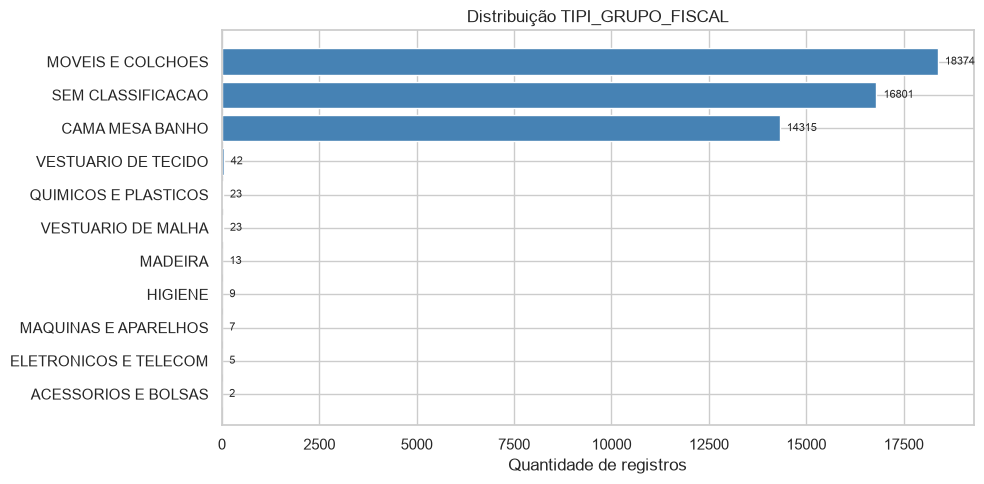

In [72]:
grupo_counts = df['TIPI_GRUPO_FISCAL'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.barh(grupo_counts.index[::-1], grupo_counts.values[::-1], color='steelblue', edgecolor='white')
plt.title('Distribuição TIPI_GRUPO_FISCAL')
plt.xlabel('Quantidade de registros')
for i, v in enumerate(grupo_counts.values[::-1]):
    plt.text(v + max(grupo_counts.values)*0.01, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

### Top 10 TIPI_FAMILIA_COMERCIAL

Ranking das famílias comerciais mais frequentes, destacando Cama, Banho e Colchoes como os grupos dominantes (≈65% do faturamento).

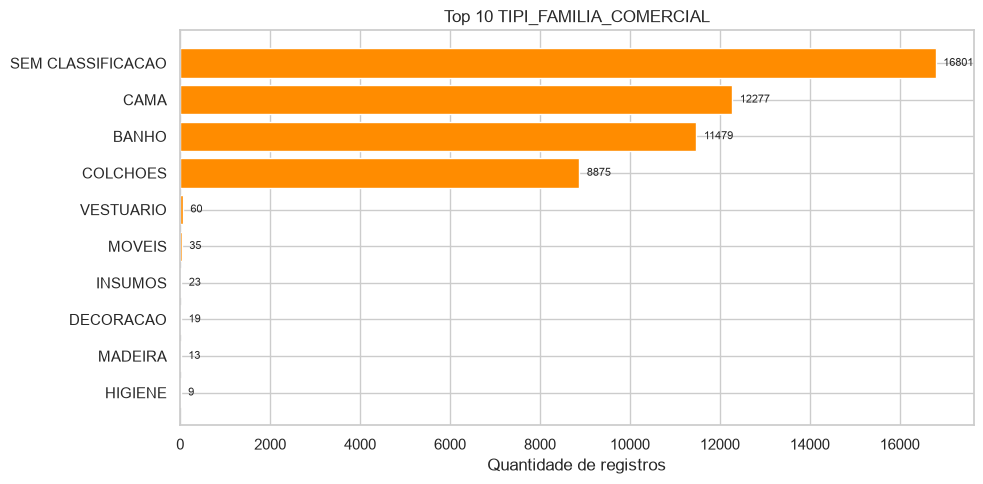

In [73]:
fam_counts = df['TIPI_FAMILIA_COMERCIAL'].value_counts().head(10)

plt.figure(figsize=(10, 5))
bars = plt.barh(fam_counts.index[::-1], fam_counts.values[::-1], color='darkorange', edgecolor='white')
plt.title('Top 10 TIPI_FAMILIA_COMERCIAL')
plt.xlabel('Quantidade de registros')
for i, v in enumerate(fam_counts.values[::-1]):
    plt.text(v + max(fam_counts.values)*0.01, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

### TIPI Válido vs Não Válido

Gráfico de barras comparando itens com classificação fiscal válida vs itens sem classificação (FRETE, serviços, etc.), evidenciando a parcela que exige tratamento especial.

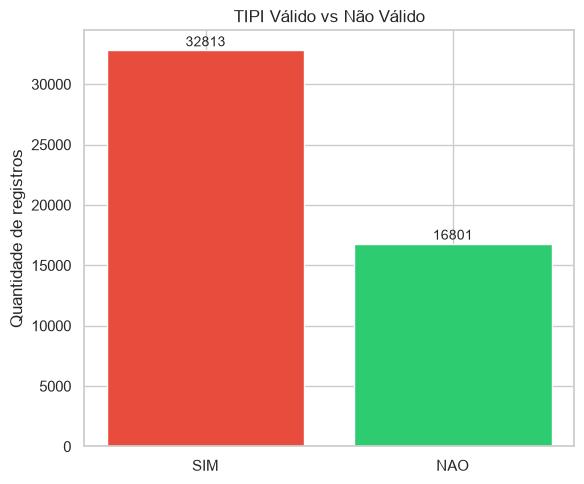

In [74]:
valido_counts = df['TIPI_VALIDO'].value_counts()

plt.figure(figsize=(6, 5))
bars = plt.bar(valido_counts.index, valido_counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='white')
plt.title('TIPI Válido vs Não Válido')
plt.ylabel('Quantidade de registros')
for i, v in enumerate(valido_counts.values):
    plt.text(i, v + max(valido_counts.values)*0.01, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [75]:
def classificar_tipo_item(ds_produto, cd_tipi):
    ds = str(ds_produto).upper().strip()
    cd = str(cd_tipi).strip()

    if ds == 'FRETE':
        return 'FRETE'
    if 'SERVICO' in ds:
        return 'SERVICO'
    if 'COMISSAO' in ds:
        return 'COMISSAO'
    if 'CREDITO PRESUMIDO' in ds:
        return 'AJUSTE FISCAL'
    if 'ADMINISTRACAO' in ds:
        return 'LANCAMENTO ADMINISTRATIVO'
    if cd == '00000000':
        return 'NAO CLASSIFICADO'
    return 'PRODUTO'

df['TIPO_ITEM_FISCAL'] = df.apply(
    lambda row: classificar_tipo_item(row['DS_PRODUTO'], row['CD_TIPI']),
    axis=1
)

In [76]:
print(df['TIPO_ITEM_FISCAL'].value_counts(normalize=True).mul(100))

TIPO_ITEM_FISCAL
PRODUTO                      66.136574
FRETE                        33.415971
SERVICO                       0.401096
COMISSAO                      0.042327
LANCAMENTO ADMINISTRATIVO     0.002016
AJUSTE FISCAL                 0.002016
Name: proportion, dtype: float64


In [77]:
(
    df.groupby('TIPO_ITEM_FISCAL')
      .agg(
          QTD_LINHAS=('NR_ITEM', 'size'),
          QTD_ITENS=('QT_FATURADO', 'sum'),
          VL_TOTALBRUTO=('VL_TOTALBRUTO', 'sum'),
          VL_TOTALDESC=('VL_TOTALDESC', 'sum'),
          VL_TOTALLIQUIDO=('VL_TOTALLIQUIDO', 'sum')
      )
      .sort_values('VL_TOTALBRUTO', ascending=False)
)


- ```PRODUTO``` concentra a operação principal da base, com 32.813 linhas, 57.772 itens e VL_TOTALBRUTO de R$ 11.710.653,63. Esse é o núcleo natural da análise comercial de mercadoria.

- ```FRETE``` aparece com 16.579 linhas e R$ 1.092.754,57. Isso é muito relevante. Em volume, é enorme e claramente é uma parcela importante da movimentação financeira.

- ```SERVICO``` tem só 199 linhas, mas quase R$ 982.983,57. Então é um bloco pequeno em volume e grande em valor médio.

- ```COMISSAO``` tem só 21 linhas e R$ 739.720,62. Isso é fortíssimo: quase nada em quantidade, mas muito representativo em valor.

- ```AJUSTE FISCAL``` aparece em 1 linha com R$ 603.747,69.

- ```LANCAMENTO ADMINISTRATIVO``` também apareceu isolado, com R$ 21.000,00.

### Quantidade de linhas por TIPO_ITEM_FISCAL

Barras horizontais do número de registros, mostrando o alto volume documental do FRETE versus a baixa frequência de COMISSAO e AJUSTE FISCAL.

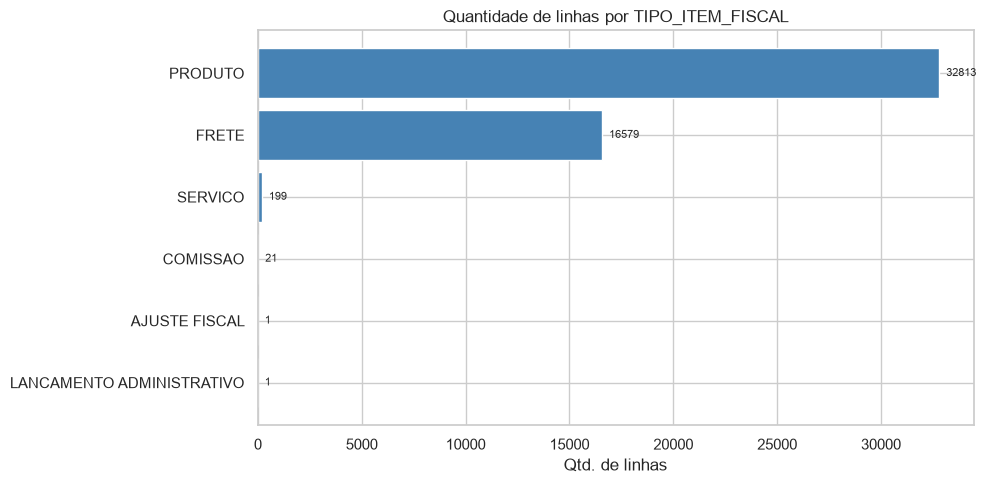

In [78]:
resumo = (
    df.groupby('TIPO_ITEM_FISCAL')
      .agg(QTD_LINHAS=('NR_ITEM', 'size'),
           VL_TOTALBRUTO=('VL_TOTALBRUTO', 'sum'))
      .sort_values('VL_TOTALBRUTO', ascending=False)
)

plt.figure(figsize=(10, 5))
plt.barh(resumo.index[::-1], resumo['QTD_LINHAS'].values[::-1], color='steelblue', edgecolor='white')
plt.title('Quantidade de linhas por TIPO_ITEM_FISCAL')
plt.xlabel('Qtd. de linhas')
for i, v in enumerate(resumo['QTD_LINHAS'].values[::-1]):
    plt.text(v + max(resumo['QTD_LINHAS'])*0.01, i, str(v), va='center', fontsize=8)
plt.tight_layout()
plt.show()

### VL_TOTALBRUTO por TIPO_ITEM_FISCAL

Barras horizontais (escala log) do valor bruto total, contrastando com o gráfico anterior: PRODUTO domina o valor, enquanto FRETE tem alto volume mas baixo ticket médio, e COMISSAO/SERVICO/AJUSTE têm poucas linhas mas alto impacto monetário.

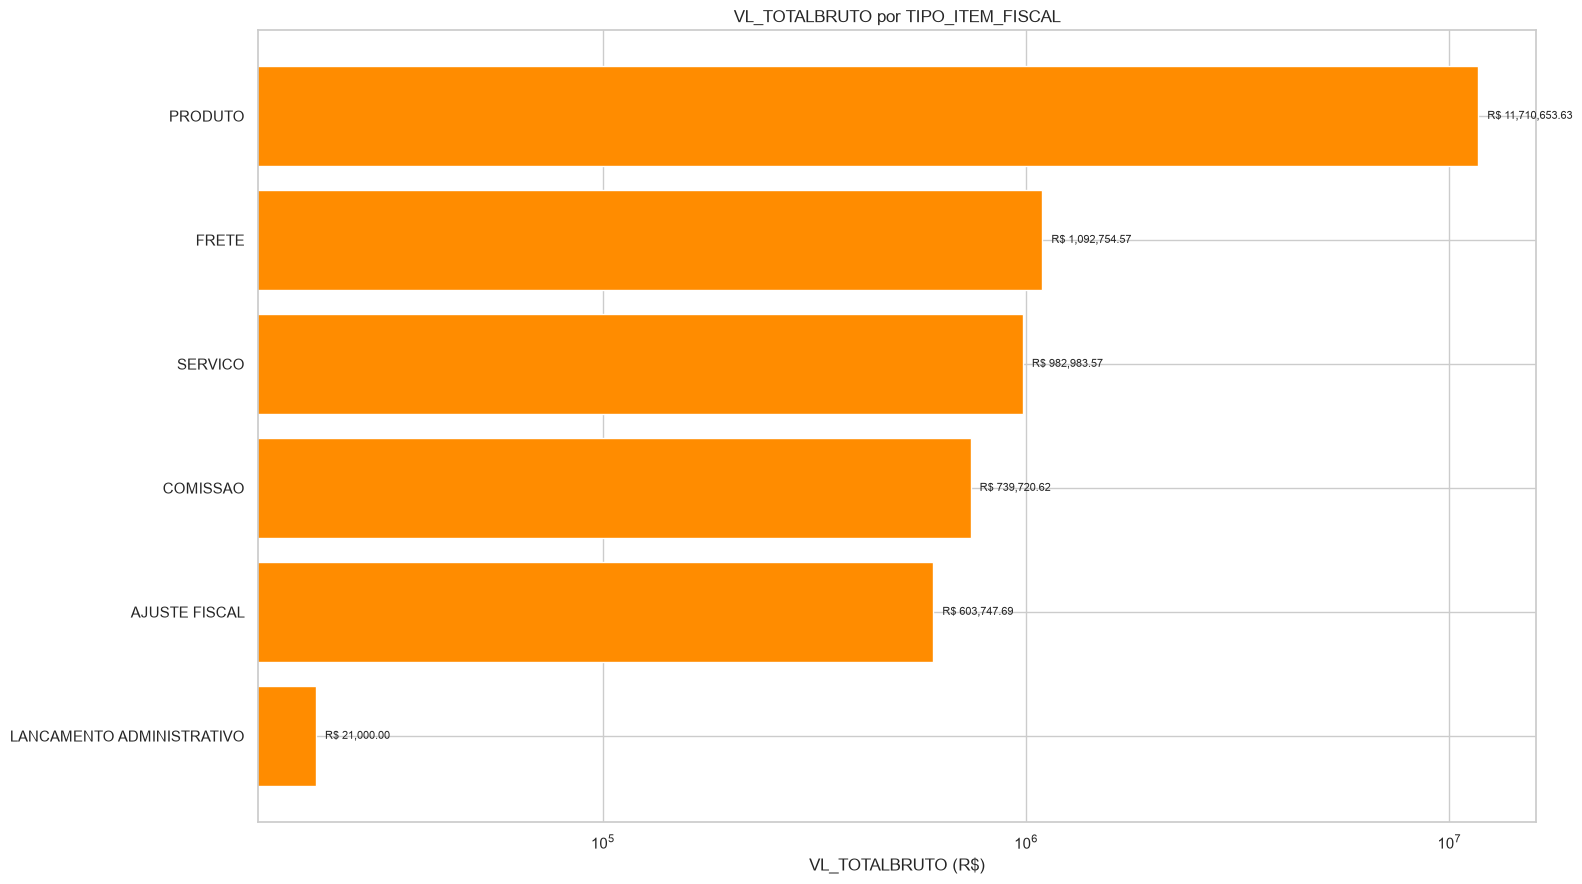

In [79]:
plt.figure(figsize=(16, 9))
plt.barh(resumo.index[::-1], resumo['VL_TOTALBRUTO'].values[::-1], color='darkorange', edgecolor='white')
plt.title('VL_TOTALBRUTO por TIPO_ITEM_FISCAL')
plt.xlabel('VL_TOTALBRUTO (R$)')
plt.xscale('log')
for i, v in enumerate(resumo['VL_TOTALBRUTO'].values[::-1]):
    if v > 0:
        plt.text(v * 1.05, i, f'R$ {v:,.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

In [80]:
(
    df.groupby(['TIPO_ITEM_FISCAL', 'CFOP_TIPO_OPERACAO'])
      .agg(
          QTD_LINHAS=('NR_ITEM', 'size'),
          VL_TOTALBRUTO=('VL_TOTALBRUTO', 'sum'),
          VL_TOTALLIQUIDO=('VL_TOTALLIQUIDO', 'sum')
      )
      .sort_values(['TIPO_ITEM_FISCAL', 'VL_TOTALBRUTO'], ascending=[True, False])
)


A primeira leitura é muito clara:

- Produto domina a base
- Frete tem presença documental muito alta
- Os demais itens são residuais em quantidade, mas alguns são representativos em volume.

Aqui aparece um ponto importante: 
 - não-produto é 33.86% das linha, mas representa 22.71% do valor bruto

Isso significa que os itens não-produto têm peso financeiro relevante, mas bem menor do que seu peso documental.

O frete representa 33.42% das linhas, mas só 7.21% do valor bruto. Isso sugere que:

- O frete aparece em muitas transações, mas com ticket unitário relativamente baixo.
- Provavelmente acompanha a operação comercial de forma quase “estrutural”.
- É um item com alto volume documental e peso financeiro moderado.

Serviço representa só 199 linhasm, mas 6.49% do valor bruto. Isso indica alto valor por ocorrência.

Comissão é ainda mais forte nesse sentido, com apenas 21 linhas mas 4.88% do valor bruto. Ou seja, baixíssima frequência e alto impacto monetário.

Ajuste fiscal contém apenas 1 linha, mas ela representa 3.99% do valor bruto total. Isso é muito relevante. Não é problema necessariamente, mas é um item que merece tratamento especial em qualquer análise gerencial.

Lançamento administrativo conta com 1 linha em AQUISICAO SERVICO ISSQN. Faz sentido, dependendo da natureza contábil do lançamento. Não chama atenção como erro estrutural.

--- 

#### A parte central da base: PRODUTO

Aqui está o coração do diagnóstico. 

As principais naturezas de operação para PRODUTO são:

- VENDA CONSUMIDOR FINAL: 19.969 linhas
- TRANSFERENCIA: 8.399
- DEVOLUCAO: 1.353
- VENDA: 1.698

Só esses quatro grupos somam 31.419 linhas de 32.813 linhas de produto, ou seja, cerca de 95,8% das linhas de produto.

Isso é excelente, porque mostra que o universo de mercadoria está concentrado em operações mercantis clássicas. Em valor bruto, a lógica também se mantém:

- VENDA CONSUMIDOR FINAL: 7.175.724,55
- TRANSFERENCIA: 2.599.137,33
- DEVOLUCAO: 748.348,75
- VENDA: 694.451,70

Esses quatro blocos representam praticamente todo o valor de PRODUTO.

#### Leitura de negócio sobre PRODUTO

O perfil operacional da sua base parece ser algo como:

- Forte peso de venda para não contribuinte
- Peso relevante de transferência
- Algum volume de devolução
- Menor participação de venda contribuinte/normal

Isso sugere uma operação com bastante movimentação entre estabelecimentos e forte saída para consumidor final ou operações tratadas como não contribuinte.

#### Operações de depósito e armazém

Também há em PRODUTO:

- OPERACAO DEPOSITO ARMAZEM_GERAL
- RETORNO SIMBOLICO DEPOSITO ARMAZEM_GERAL
- RETORNO DEPOSITO ARMAZEM_GERAL

Essas naturezas são coerentes com produto. Não parecem ruído, indicam movimentações logísticas/fiscais que continuam sendo de mercadoria.

Isso é importante porque evita uma visão simplista de “produto = só venda”.

---

### Heatmap: CFOP_TIPO_OPERACAO x TIPO_ITEM_FISCAL

Percentuais por linha mostrando como cada tipo de operação se distribui entre produto, frete, serviço, etc. PRODUTO domina as vendas e transferências, enquanto FRETE concentra-se em aquisição de serviço de transporte.

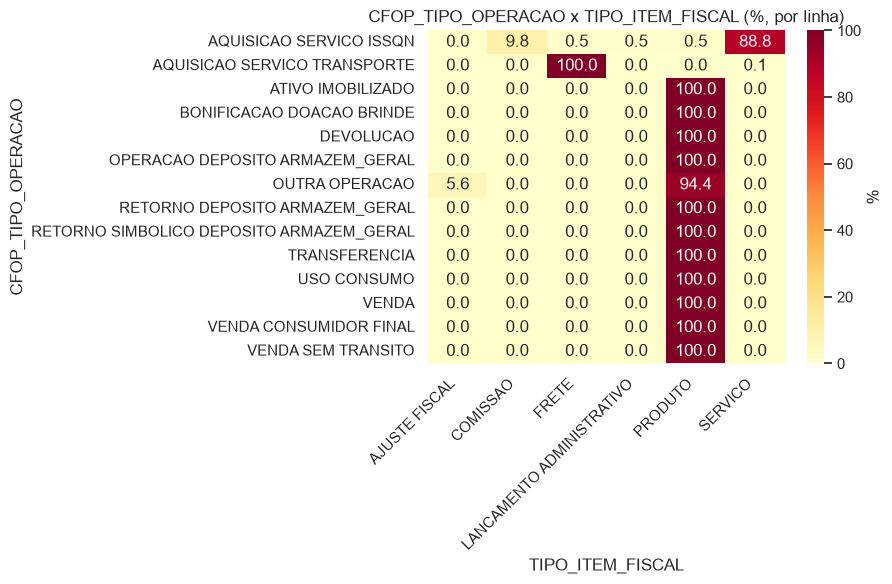

In [81]:
ct1 = pd.crosstab(df['CFOP_TIPO_OPERACAO'], df['TIPO_ITEM_FISCAL'], normalize='index').mul(100).round(2)

plt.figure(figsize=(9, 6))
sns.heatmap(ct1, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '%'})
plt.title('CFOP_TIPO_OPERACAO x TIPO_ITEM_FISCAL (%, por linha)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Heatmap: CFOP_TIPO_OPERACAO x CST_GRUPO

Percentuais por linha evidenciando como cada operação se distribui entre os grupos de tributação (tributado, isento, não tributado, etc.).

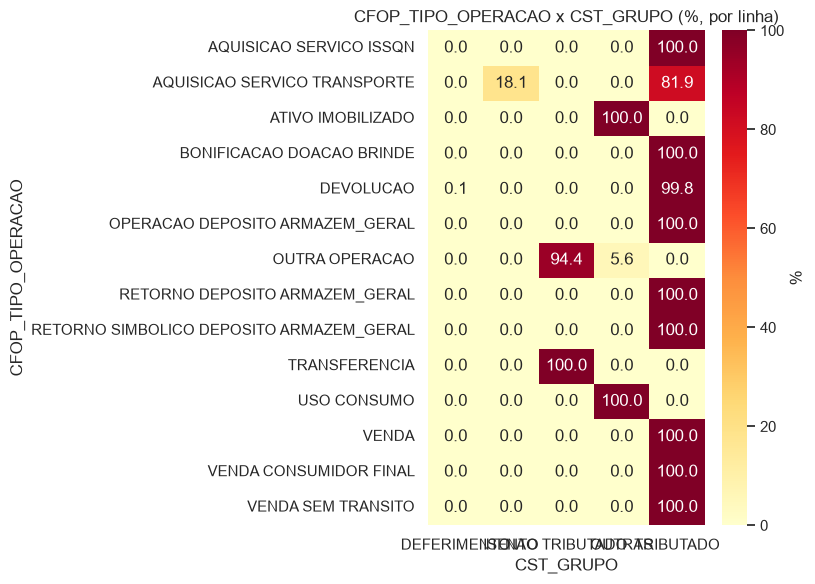

In [82]:
ct2 = pd.crosstab(df['CFOP_TIPO_OPERACAO'], df['CST_GRUPO'], normalize='index').mul(100).round(2)

plt.figure(figsize=(8, 6))
sns.heatmap(ct2, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '%'})
plt.title('CFOP_TIPO_OPERACAO x CST_GRUPO (%, por linha)')
plt.tight_layout()
plt.show()

### Heatmap: TIPI_GRUPO_FISCAL x CFOP_TIPO_OPERACAO

Percentuais por linha mostrando como cada grupo fiscal TIPI se distribui entre os tipos de operação CFOP, evidenciando concentrações como vendas de móveis/colchões e frete em itens sem classificação.

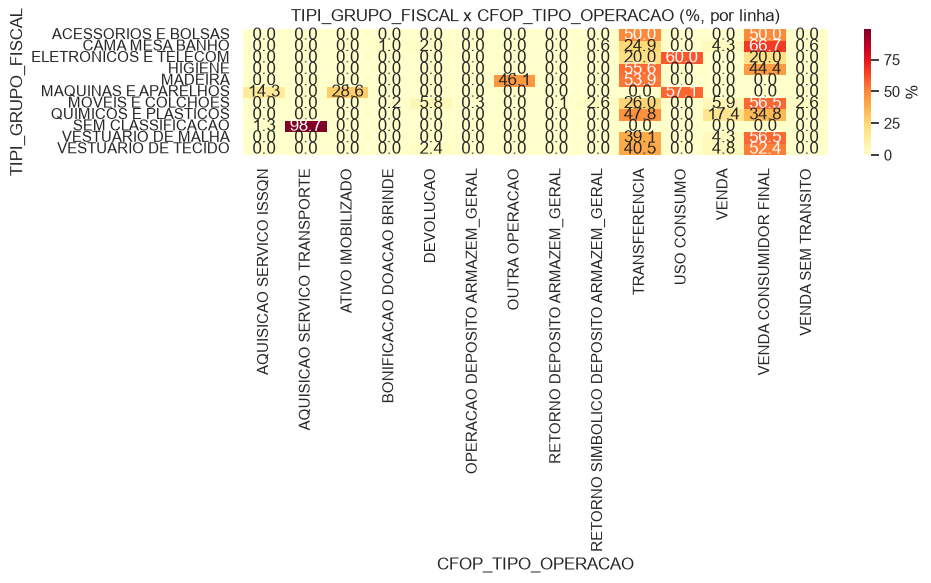

In [83]:
ct3 = pd.crosstab(df['TIPI_GRUPO_FISCAL'], df['CFOP_TIPO_OPERACAO'], normalize='index').mul(100).round(2)

plt.figure(figsize=(10, 6))
sns.heatmap(ct3, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '%'})
plt.title('TIPI_GRUPO_FISCAL x CFOP_TIPO_OPERACAO (%, por linha)')
plt.tight_layout()
plt.show()

### Heatmap: TIPI_FAMILIA_COMERCIAL x CST_GRUPO

Percentuais por linha mostrando a tributação dentro de cada família comercial, evidenciando quais famílias são mais tributadas, isentas ou não tributadas.

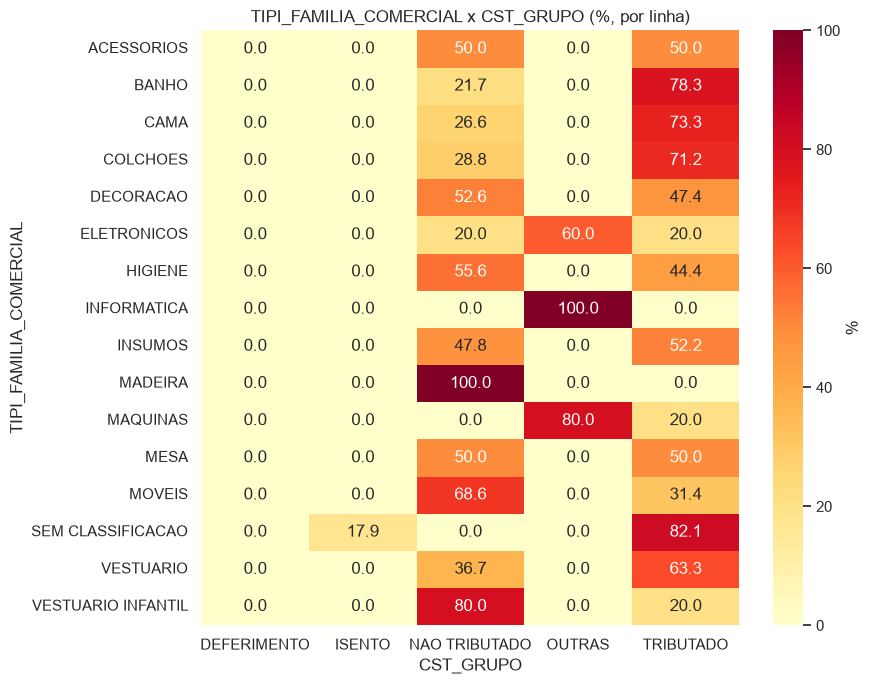

In [84]:
ct4 = pd.crosstab(df['TIPI_FAMILIA_COMERCIAL'], df['CST_GRUPO'], normalize='index').mul(100).round(2)

plt.figure(figsize=(9, 7))
sns.heatmap(ct4, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '%'})
plt.title('TIPI_FAMILIA_COMERCIAL x CST_GRUPO (%, por linha)')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [85]:
pd.crosstab(df['CFOP_TIPO_OPERACAO'], df['TIPO_ITEM_FISCAL'], normalize='index').sort_values(by='PRODUTO').round(4).mul(100)

In [86]:
pd.crosstab(df['CFOP_TIPO_OPERACAO'], df['CST_GRUPO'], normalize='index').sort_values(by='TRIBUTADO').round(4).mul(100)

In [87]:
pd.crosstab(df['TIPI_GRUPO_FISCAL'], df['CFOP_TIPO_OPERACAO'], normalize='index').round(4).mul(100)

In [88]:
pd.crosstab(df['TIPI_FAMILIA_COMERCIAL'], df['CST_GRUPO'], normalize='index').sort_values(by='TRIBUTADO').round(4).mul(100)

# Conclusão

A análise exploratória de `FIS_NFITEM.csv` mostrou que a base possui **49.614 registros** e combina itens de mercadoria com fretes, serviços, comissões e lançamentos de natureza administrativa ou fiscal. Portanto, a soma direta dos campos de valor não representa automaticamente faturamento comercial. A granularidade é de item de nota, e qualquer métrica de receita deve respeitar a classificação fiscal da operação e o vínculo com o cabeçalho da nota.

## Qualidade e preparação dos dados

As colunas `CD_DEST` e `CD_DECRETO` foram removidas por apresentarem 100% de nulidade. Os campos monetários ausentes foram tratados como ausência de valor, sem imputação estatística, e `IN_DESCONTO` foi reconstruído de acordo com `VL_TOTALDESC`. A coluna `VL_SEGURO` não apresentou valores diferentes de zero. Datas, códigos CFOP e códigos TIPI foram padronizados, resultando em uma base tratada com 27 colunas originais e novas dimensões analíticas derivadas.

Os valores e quantidades apresentam forte assimetria e muitos outliers. Esse comportamento é compatível com uma base transacional que mistura vendas unitárias, movimentações de estoque e lançamentos de alto valor. As colunas `CD_EMPRESA`, `CD_EMPFAT` e `CD_GRUPOEMPRESA` possuem valor único no recorte, impedindo comparação real entre empresas nesta amostra.

## Estrutura fiscal e operacional

O mapeamento do CST indica predominância de mercadorias nacionais. Aproximadamente **76,95%** dos itens são tributados integralmente, **16,96%** são não tributados e **6,06%** são isentos. O CFOP revelou uma operação majoritariamente interestadual: **69,34%** dos registros pertencem a movimentos entre estados. As principais classificações são `VENDA CONSUMIDOR FINAL` (**40,25%**), `AQUISICAO SERVICO TRANSPORTE` (**33,43%**), `TRANSFERENCIA` (**16,93%**), `VENDA` (**3,42%**) e `DEVOLUCAO` (**2,73%**).

Essa distribuição confirma que a base não contém somente vendas. Transferências, aquisições de transporte, devoluções, depósitos, bonificações, uso e consumo e outras operações precisam permanecer separadas do universo de faturamento. O CFOP mostrou-se a principal dimensão para interpretar fluxo, abrangência e natureza econômica do item.

## Perfil dos itens

A classificação `TIPO_ITEM_FISCAL` separou o conjunto em **66,14% de linhas de produto** e **33,86% de linhas de não-produto**. Produtos concentram 32.813 linhas, 57.772 unidades e R$ 11.710.653,63 de valor bruto. Apesar de representarem cerca de um terço dos registros, os não-produtos respondem por aproximadamente **22,71% da movimentação bruta**, demonstrando relevância financeira e necessidade de tratamento explícito.

O frete possui 16.579 linhas e R$ 1.092.754,57 de valor bruto: alta frequência documental, mas participação financeira proporcionalmente menor. Serviços aparecem em apenas 199 linhas, porém somam R$ 982.983,57. Comissões possuem 21 ocorrências e R$ 739.720,62, enquanto um único ajuste fiscal representa R$ 603.747,69. Esses casos mostram que baixa frequência não significa baixa materialidade.

Dentro do universo de produtos, `VENDA CONSUMIDOR FINAL`, `TRANSFERENCIA`, `DEVOLUCAO` e `VENDA` concentram aproximadamente **95,8% das linhas**. A TIPI reforça o perfil comercial do conjunto: as famílias `CAMA`, `BANHO` e `COLCHOES` representam aproximadamente **65,77% dos registros**. Entretanto, **33,86%** das linhas permanecem sem classificação TIPI, principalmente devido à presença de itens que não representam mercadorias.

## Direcionamento analítico

A base tratada está adequada para análises em nível de item, produto, unidade, CFOP, CST e TIPI. Para apurar faturamento, porém, é necessário integrá-la ao cabeçalho das notas, validar a situação documental e aplicar uma regra explícita de inclusão e exclusão. Produtos associados a operações de venda devem formar o universo de receita; devoluções devem ser tratadas separadamente como abatimento; transferências e itens não comerciais devem permanecer disponíveis para auditoria, sem compor faturamento.

As classificações criadas — especialmente `CFOP_TIPO_FLUXO`, `CFOP_TIPO_OPERACAO`, `TIPI_GRUPO_FISCAL`, `TIPI_FAMILIA_COMERCIAL` e `TIPO_ITEM_FISCAL` — constituem a principal entrega desta etapa. Elas transformam códigos fiscais em dimensões de negócio e fornecem a base necessária para uma integração auditável com `NF.csv` e para a construção das métricas comerciais posteriores. Os mapeamentos permanecem sujeitos à validação da empresa, principalmente nos casos de serviço, comissão, ajuste fiscal e lançamentos administrativos.


In [90]:
df.to_csv(DATA_DIR / "NFITEM.csv", index=None)